# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-04-22 11:31:03.050074: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 11:31:03.102325: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 11:31:04.627426: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/OLTREMARE/RAW_RECORDINGS'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/OLTREMARE'

#@markdown Path to your single annotation JSON file
annotation_json_path = '/data2/mromaniuc/cet-det/datasets/OLTREMARE/annotations.json'  #@param {type:'string'}

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1776850275.245925 1744245 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1776850275.637946 1744245 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


In [ ]:
#@title Parse annotations and build window list (Oltremare)

from pathlib import Path
from collections import Counter

with open(annotation_json_path) as f:
    annot = json.load(f)

wav_folder = Path(wav_folder)
windows = []
missing_wavs = []

for wav_stem, annotations in annot['files'].items():
    wav_path = wav_folder / f'{wav_stem}.wav'

    if not wav_path.exists():
        missing_wavs.append(str(wav_path))
        continue

    duration = librosa.get_duration(path=str(wav_path))
    n_windows = int(duration // window_size_s)

    for i in range(n_windows):
        win_start = i * window_size_s
        win_end = win_start + window_size_s

        n_echolocation = 0
        n_burst_pulse = 0
        n_feeding_buzz = 0
        n_whistles = 0
        n_noise = 0

        for ann in annotations:
            overlap = min(win_end, ann['end']) - max(win_start, ann['start'])
            if overlap >= min_overlap_s:
                lbl = ann['label']
                if lbl == 'echolocation':
                    n_echolocation += 1
                elif lbl == 'burst_pulse':
                    n_burst_pulse += 1
                elif lbl == 'feeding_buzz':
                    n_feeding_buzz += 1
                elif lbl in ('whistle', 'm_whistle'):
                    n_whistles += 1
                elif lbl == 'noise':
                    n_noise += 1

        # Build label from all present classes
        present = []
        if n_whistles > 0: present.append('whistle')
        if n_echolocation > 0: present.append('echolocation')
        if n_burst_pulse > 0: present.append('burst_pulse')
        if n_feeding_buzz > 0: present.append('feeding_buzz')

        label = '+'.join(sorted(present)) if present else 'background'

        windows.append({
            'wav_path': str(wav_path),
            'offset_s': win_start,
            'label': label,
            'n_echolocation': n_echolocation,
            'n_burst_pulse': n_burst_pulse,
            'n_feeding_buzz': n_feeding_buzz,
            'n_whistles': n_whistles,
            'n_noise': n_noise,
        })

windows_df = pd.DataFrame(windows)

print(f'Total windows: {len(windows_df)}')
print(f'Files processed: {len(annot["files"]) - len(missing_wavs)}')
if missing_wavs:
    print(f'WARNING: {len(missing_wavs)} WAV files not found (first 10: {missing_wavs[:10]})')

print('\n=== Label distribution ===')
print(windows_df['label'].value_counts().to_string())

print('\n=== Per-type stats ===')
for col, name in [('n_whistles', 'Whistle'), ('n_echolocation', 'Echolocation'),
                   ('n_burst_pulse', 'Burst Pulse'), ('n_feeding_buzz', 'Feeding Buzz'),
                   ('n_noise', 'Noise')]:
    has = windows_df[windows_df[col] > 0]
    if len(has):
        print(f'  {name}: {len(has)} windows, mean={has[col].mean():.1f}, max={has[col].max()}')
    else:
        print(f'  {name}: 0 windows')

Total windows: 16860
Files processed: 281

=== Label distribution ===
label
background                                       13956
whistle                                           1629
echolocation                                       424
burst_pulse                                        349
feeding_buzz                                       152
burst_pulse+whistle                                 80
echolocation+whistle                                74
burst_pulse+echolocation                            54
feeding_buzz+whistle                                50
burst_pulse+feeding_buzz                            31
echolocation+feeding_buzz                           18
burst_pulse+feeding_buzz+whistle                    16
echolocation+feeding_buzz+whistle                    9
burst_pulse+echolocation+whistle                     9
burst_pulse+echolocation+feeding_buzz                6
burst_pulse+echolocation+feeding_buzz+whistle        3

=== Per-type stats ===
  Whistle: 1870 wind

  ### Overlap Resolution Strategy
 
  When multiple vocalization types co-occur within a 5-second window
  (e.g., a whistle overlapping with echolocation clicks), we assign
  the window to the **rarest class present**. The rarity ranking,
  derived from the pure-class counts in this dataset, is:
  feeding_buzz (152) < burst_pulse (349) < echolocation (424) < whistle (1629) < background (13956).
 
  This strategy maximizes representation of minority classes, which are
  both the most informative for classification and the hardest to collect.
  Only ~2% of windows (350/16860) contain overlapping labels, so the
  impact on majority classes is negligible. The original composite labels
  are preserved in `label_raw` for reference.

In [9]:
#@title Resolve overlapping labels → assign to rarest class present

rarity_order = ['feeding_buzz', 'burst_pulse', 'echolocation', 'whistle', 'background']

def resolve_label(label):
    if '+' not in label:
        return label
    parts = label.split('+')
    for cls in rarity_order:
        if cls in parts:
            return cls
    return label  # fallback

windows_df['label_raw'] = windows_df['label']
windows_df['label'] = windows_df['label_raw'].apply(resolve_label)

print('=== Resolved label distribution ===')
print(windows_df['label'].value_counts().to_string())

print('\n=== Combo resolution breakdown ===')
combos = windows_df[windows_df['label_raw'].str.contains(r'\+', regex=True)]
if len(combos):
    resolution = combos.groupby(['label_raw', 'label']).size().reset_index(name='count')
    for _, row in resolution.iterrows():
        print(f'  {row["label_raw"]:50s} → {row["label"]:20s} (n={row["count"]})')
print(f'\nTotal combo windows resolved: {len(combos)}')

=== Resolved label distribution ===
label
background      13956
whistle          1629
echolocation      498
burst_pulse       492
feeding_buzz      285

=== Combo resolution breakdown ===
  burst_pulse+echolocation                           → burst_pulse          (n=54)
  burst_pulse+echolocation+feeding_buzz              → feeding_buzz         (n=6)
  burst_pulse+echolocation+feeding_buzz+whistle      → feeding_buzz         (n=3)
  burst_pulse+echolocation+whistle                   → burst_pulse          (n=9)
  burst_pulse+feeding_buzz                           → feeding_buzz         (n=31)
  burst_pulse+feeding_buzz+whistle                   → feeding_buzz         (n=16)
  burst_pulse+whistle                                → burst_pulse          (n=80)
  echolocation+feeding_buzz                          → feeding_buzz         (n=18)
  echolocation+feeding_buzz+whistle                  → feeding_buzz         (n=9)
  echolocation+whistle                               → echolocation  

just to check wether we correctly assigned the labels:

In [10]:
#@title Visualize window labels — all files in one plot (Oltremare, 5-class)

from matplotlib.patches import Patch

label_colors = {
    'background': '#d3d3d3',
    'whistle': '#e67e22',
    'echolocation': '#4682b4',
    'burst_pulse': '#8e44ad',
    'feeding_buzz': '#e74c3c',
}

ann_colors = {
    'whistle': '#2ecc71',
    'm_whistle': '#2ecc71',
    'echolocation': '#3498db',
    'burst_pulse': '#9b59b6',
    'feeding_buzz': '#e74c3c',
    'noise': '#999999',
}

files = windows_df['wav_path'].unique()
n_files = len(files)

fig, axes = plt.subplots(n_files, 1, figsize=(15, 2.5 * n_files))
if n_files == 1:
    axes = [axes]

for ax, wav_path in zip(axes, files):
    file_windows = windows_df[windows_df['wav_path'] == wav_path]
    duration = file_windows['offset_s'].max() + window_size_s
    wav_stem = Path(wav_path).stem
    file_anns = annot['files'].get(wav_stem, [])

    # Draw window labels
    for _, row in file_windows.iterrows():
        color = label_colors.get(row['label'], 'gray')
        ax.barh(0, window_size_s, left=row['offset_s'], height=0.5,
                color=color, edgecolor='white', linewidth=0.3)

    # Overlay raw annotations
    for ann in file_anns:
        color = ann_colors.get(ann['label'], '#999999')
        ax.barh(0.6, ann['end'] - ann['start'], left=ann['start'],
                height=0.2, color=color, alpha=0.7)

    ax.set_xlim(0, duration)
    ax.set_yticks([0, 0.6])
    ax.set_yticklabels(['windows', 'annotations'], fontsize=6)
    ax.set_xlabel('Time (s)', fontsize=6)
    ax.set_title(f'{wav_stem}  ({len(file_windows)} win)', fontsize=7)
    ax.tick_params(axis='x', labelsize=6)

# Legend on first axis
legend_elements = [
    Patch(facecolor=v, label=k) for k, v in label_colors.items()
] + [
    Patch(facecolor='#2ecc71', label='raw whistle'),
    Patch(facecolor='#3498db', label='raw ECT'),
    Patch(facecolor='#9b59b6', label='raw BPS'),
    Patch(facecolor='#e74c3c', label='raw FB'),
    Patch(facecolor='#999999', label='raw NOISE'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=5, ncol=5)

plt.suptitle(f'Oltremare — {n_files} files, {len(windows_df)} windows', fontsize=10)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/visualize_windows.png', dpi=100, bbox_inches='tight')
plt.close()
print(f'Saved — {n_files} files in one plot')

Saved — 281 files in one plot


~45 minutes to run for 3290 samples of 5s resampled from 512khz

In [11]:
import soxr
from tqdm import tqdm

embeddings_list, logits_list, labels_list, failed_idx = [], [], [], []
windows_df = windows_df.reset_index(drop=True)

for i, row in tqdm(windows_df.iterrows(), total=len(windows_df)):
    try:
        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        audio = soxr.resample(audio_native, native_sr, sr)
        target_len = int(window_size_s * sr)
        if len(audio) < target_len:
            audio = np.pad(audio, (0, target_len - len(audio)))
        audio = audio[:target_len].astype(np.float32)

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])
    except Exception as e:
        failed_idx.append(i)
        print(f'  FAILED [{i}] {Path(row["wav_path"]).name} @ {row["offset_s"]:.1f}s — {repr(e)}')
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(windows_df)} embedded...')

X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f'\nDone. {len(X)} embedded, {len(failed_idx)} failed.')
print(f'Embedding shape: {X.shape}')

  0%|          | 0/16860 [00:00<?, ?it/s]2026-04-21 15:49:35.884723: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fb7ac06dca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-21 15:49:35.884765: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-04-21 15:49:36.201910: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-21 15:49:36.245550: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92100
2026-04-21 15:49:37.118981: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 68 bytes spill stores, 68 bytes spill loads

2026-04-21 15:49:37.386715: I external/local_xla/xla/stream_executor/cuda/subprocess_c

  100/16860 embedded...


  1%|          | 205/16860 [00:16<07:18, 38.00it/s]

  200/16860 embedded...


  2%|▏         | 305/16860 [00:19<07:19, 37.67it/s]

...

  16700/16860 embedded...


100%|█████████▉| 16806/16860 [07:34<00:01, 38.05it/s]

  16800/16860 embedded...


100%|██████████| 16860/16860 [07:35<00:00, 36.99it/s]



Done. 16860 embedded, 0 failed.
Embedding shape: (16860, 1536)


In [ ]:
#@title Save embeddings and metadata to Drive

os.makedirs(save_dir, exist_ok=True)

# --- Build raw arrays ---
succeeded_mask = [i for i in windows_df.index if i not in set(failed_idx)]
metadata_df = windows_df.loc[succeeded_mask].copy().reset_index(drop=True)
metadata_df['embedding_idx'] = metadata_df.index

# --- NaN diagnostic ---
nan_in_X = np.isnan(X).any(axis=1)
nan_in_Z = np.isnan(Z).any(axis=1)
nan_any = nan_in_X | nan_in_Z

print('=== NaN DIAGNOSTIC ===')
print(f'Total windows:          {len(X)}')
print(f'Rows with NaN in X:     {nan_in_X.sum()}')
print(f'Rows with NaN in Z:     {nan_in_Z.sum()}')
print(f'Rows with NaN in either:{nan_any.sum()}')

if nan_any.sum() > 0:
    print('\nAffected rows:')
    for idx in np.where(nan_any)[0]:
        label = y[idx]
        wav = Path(metadata_df.iloc[idx]['wav_path']).name
        offset = metadata_df.iloc[idx]['offset_s']
        nan_x = np.isnan(X[idx]).sum()
        nan_z = np.isnan(Z[idx]).sum()
        print(f'  row {idx:5d} | {label:10s} | {wav} @ {offset:.1f}s | NaN in X: {nan_x}, NaN in Z: {nan_z}')

    pct = nan_any.sum() / len(X) * 100
    if pct < 5.0:
        print(f'\n{nan_any.sum()} NaN rows ({pct:.2f}% of data) — safe to drop, proceeding.')
        valid = ~nan_any
        X_save = X[valid]
        Z_save = Z[valid]
        y_save = y[valid]
        metadata_save = metadata_df[valid].reset_index(drop=True)
        metadata_save['embedding_idx'] = metadata_save.index
    else:
        print(f'\nWARNING: {pct:.2f}% of data has NaN — too many to drop safely, investigate first.')
        print('Saving anyway with NaNs so you do not lose data — fix before training.')
        X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df
else:
    print('\nNo NaN values found — data is clean.')
    X_save, Z_save, y_save, metadata_save = X, Z, y, metadata_df

np.save(f'{save_dir}/embeddings/X_embeddings.npy', X_save)
np.save(f'{save_dir}/embeddings/Z_logits.npy', Z_save)
np.save(f'{save_dir}/embeddings/y_labels.npy', y_save)
metadata_save.to_csv(f'{save_dir}/embeddings/metadata.csv', index=False)

print(f'\n=== SAVED TO {save_dir} ===')
print(f'  X_embeddings.npy  — {X_save.shape}')
print(f'  Z_logits.npy      — {Z_save.shape}')
print(f'  y_labels.npy      — {y_save.shape}')
print(f'  metadata.csv      — {len(metadata_save)} rows')
print(f'\nClass distribution in saved data:')
print(pd.Series(y_save).value_counts())

=== NaN DIAGNOSTIC ===
Total windows:          16860
Rows with NaN in X:     0
Rows with NaN in Z:     0
Rows with NaN in either:0

No NaN values found — data is clean.

=== SAVED TO /data2/mromaniuc/cet-det/models/perch_v2/OLTREMARE ===
  X_embeddings.npy  — (16860, 1536)
  Z_logits.npy      — (16860, 14795)
  y_labels.npy      — (16860,)
  metadata.csv      — 16860 rows

Class distribution in saved data:
background      13956
whistle          1629
echolocation      498
burst_pulse       492
feeding_buzz      285
Name: count, dtype: int64


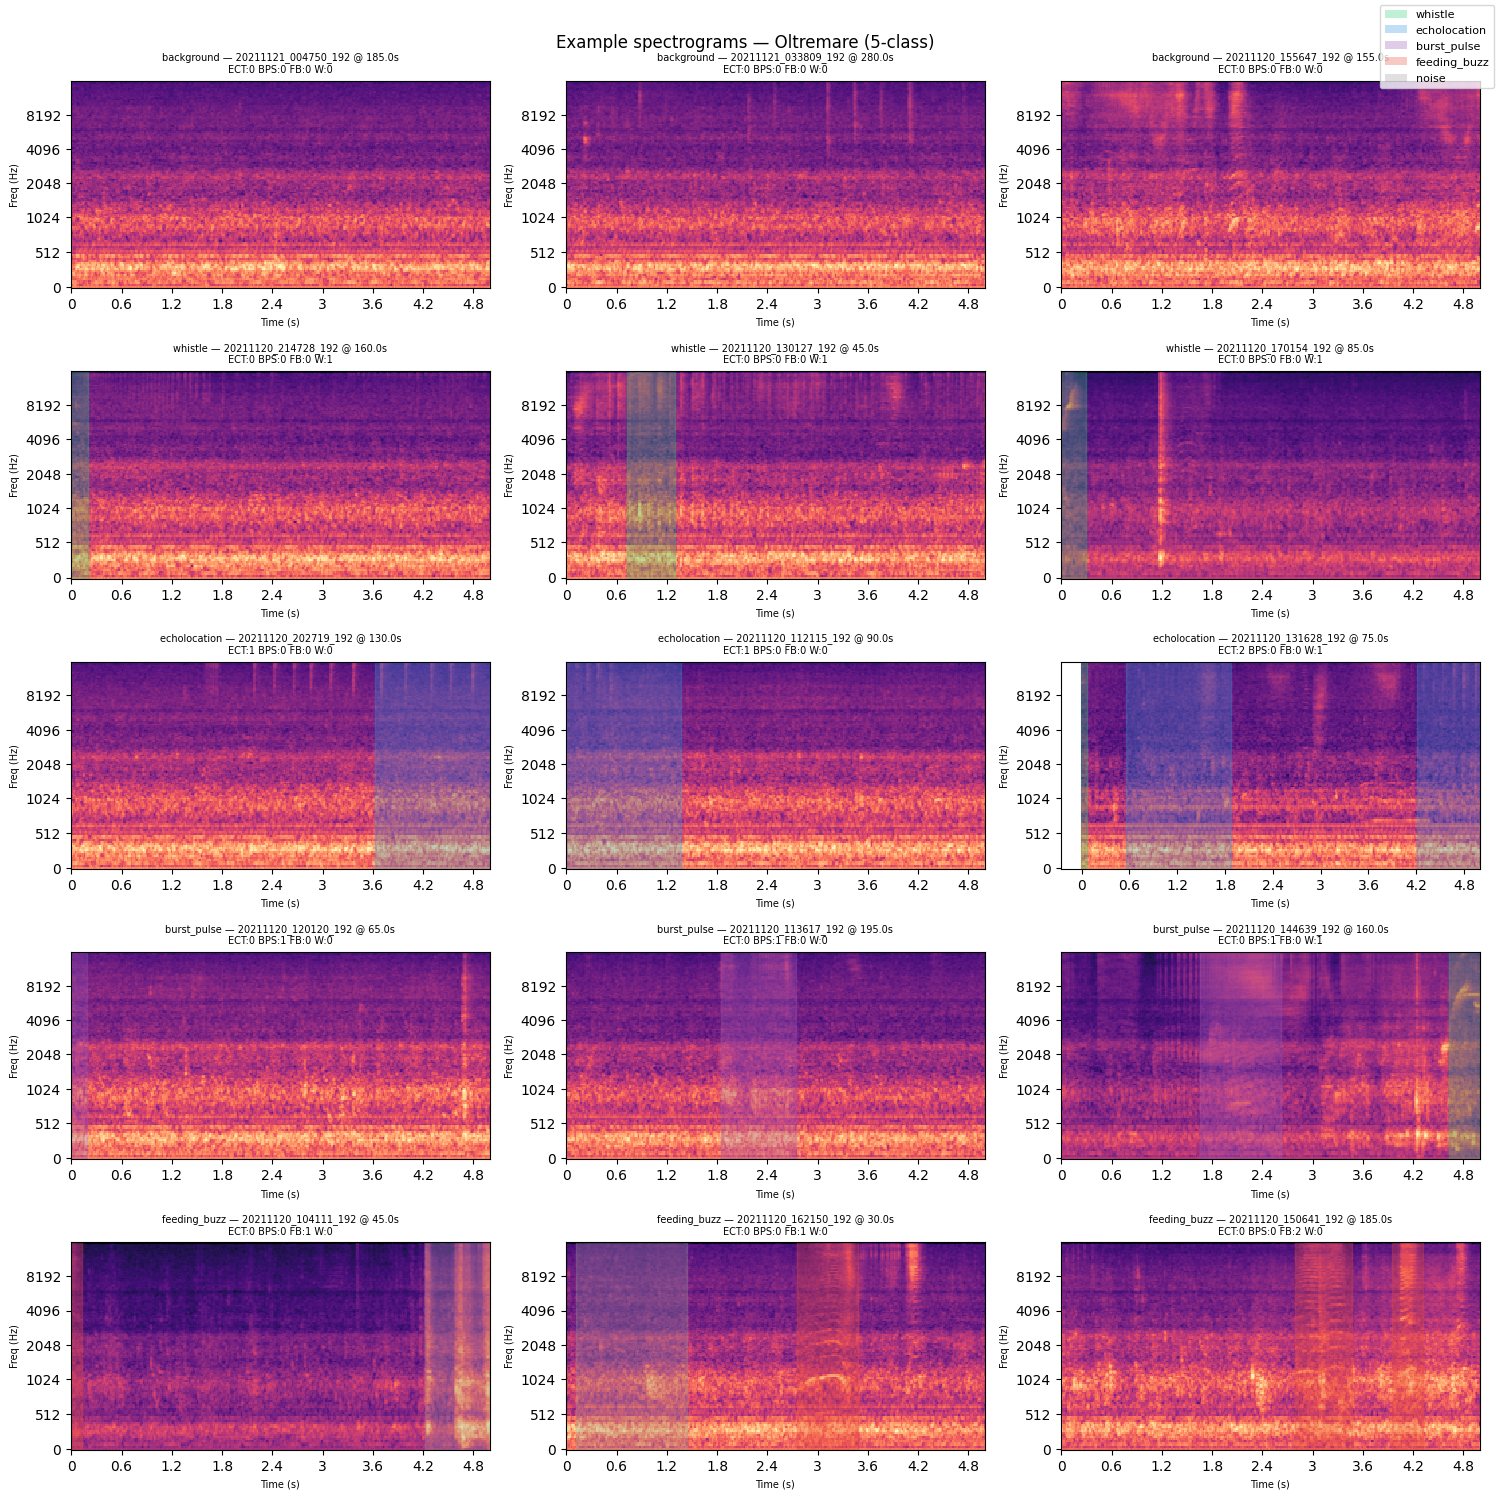

In [13]:
#@title Visualize example spectrograms (Oltremare — 5-class)

labels = ['background', 'whistle', 'echolocation', 'burst_pulse', 'feeding_buzz']
n_examples = 3
min_display_width = 0.08

ann_colors = {
    'whistle': '#2ecc71',
    'm_whistle': '#2ecc71',
    'echolocation': '#3498db',
    'burst_pulse': '#9b59b6',
    'feeding_buzz': '#e74c3c',
    'noise': '#999999',
}

fig, axes = plt.subplots(len(labels), n_examples, figsize=(15, 15))

for row_idx, label in enumerate(labels):
    subset = windows_df[windows_df['label'] == label]
    n_avail = min(n_examples, len(subset))
    samples = subset.sample(n_avail, random_state=42)

    for col_idx in range(n_examples):
        ax = axes[row_idx][col_idx]
        if col_idx >= n_avail:
            ax.axis('off')
            continue

        row = samples.iloc[col_idx]
        audio_native, native_sr = librosa.load(
            row['wav_path'], sr=None,
            offset=row['offset_s'], duration=window_size_s, mono=True
        )
        audio = soxr.resample(audio_native, native_sr, sr)

        S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=sr // 2)
        S_db = librosa.power_to_db(S, ref=np.max)

        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)

        # Overlay raw annotations within this window
        wav_stem = Path(row['wav_path']).stem
        file_anns = annot['files'].get(wav_stem, [])
        win_start = row['offset_s']
        win_end = win_start + window_size_s

        for ann in file_anns:
            if ann['end'] < win_start or ann['start'] > win_end:
                continue
            a_start = max(ann['start'], win_start) - win_start
            a_end = min(ann['end'], win_end) - win_start
            if a_end > a_start:
                width = max(a_end - a_start, min_display_width)
                center = (a_start + a_end) / 2
                color = ann_colors.get(ann['label'], '#999999')
                ax.axvspan(center - width / 2, center + width / 2,
                           color=color, alpha=0.3)

        ax.set_title(f'{label} — {wav_stem} @ {row["offset_s"]:.1f}s'
                     f'\nECT:{row["n_echolocation"]} BPS:{row["n_burst_pulse"]} '
                     f'FB:{row["n_feeding_buzz"]} W:{row["n_whistles"]}', fontsize=7)
        ax.set_xlabel('Time (s)', fontsize=7)
        ax.set_ylabel('Freq (Hz)', fontsize=7)

# Legend
from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor=v, alpha=0.3, label=k) for k, v in ann_colors.items() if k != 'm_whistle'
], loc='upper right', fontsize=8)

plt.suptitle('Example spectrograms — Oltremare (5-class)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/example_spectrograms_5class.png', dpi=150, bbox_inches='tight')
plt.show()

# retrieving the data and performing zero-shot and fully-supervised classifications

In [6]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')  
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (16860, 1536), Z: (16860, 14795), y: (16860,)
Class distribution:
background      13956
whistle          1629
echolocation      498
burst_pulse       492
feeding_buzz      285
Name: count, dtype: int64


In [14]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['dolphin', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphin', 'cetacea']):
        print(name)

print("\n--- Water/noise/background ---")
for name in perch_class_names:
    if any(term in name.lower() for term in ['water', 'noise', 'background', 'ambient', 'silence', 'rain', 'wave', 'ocean', 'sea']):
        print(name)

Colibri delphinae
Delphinapterus leucas
Myzomela adolphinae
Phylloscopus whistleri
Tursiops truncatus

--- Water/noise/background ---
Anstisia rosea
Anthus roseatus
Ardenna grisea
Boat_and_Water_vehicle
Cinnyris osea
Conocephalus oceanicus
Coracina caeruleogrisea
Ducula oceanica
Formicivora grisea
Gull_and_seagull
Lycalopex grisea
Microwave_oven
Myiagra oceanica
Myopsalta waterhousei
Myrmotherula grisea
Ocean
Oceanites gracilis
Oceanites oceanicus
Oceanites pincoyae
Petroica rosea
Platycleis grisea
Poecilimon ukrainicus
Prioniturus waterstradti
Psittacula roseata
Rain
Raindrop
Rhodinocichla rosea
Rhodostethia rosea
Sarothrura watersi
Streptopelia roseogrisea
Tachycineta euchrysea
Tamasa rainbowi
Teleogryllus oceanicus
Thalurania watertonii
Traffic_noise_and_roadway_noise
Train
Water
Water_tap_and_faucet
Waves_and_surf
Zoothera talaseae


In [7]:
#@title Zero-shot species analysis — what does Perch think your sounds are? (Oltremare, 5-class)

class_names_list = list(embedding_model.class_list['labels'].classes)

# Masks for all 5 classes
masks = {
    'background': y_clean == 'background',
    'whistle': y_clean == 'whistle',
    'echolocation': y_clean == 'echolocation',
    'burst_pulse': y_clean == 'burst_pulse',
    'feeding_buzz': y_clean == 'feeding_buzz',
}

# Mean logits per class
mean_logits = {label: Z_clean[mask].mean(axis=0) for label, mask in masks.items() if mask.sum() > 0}

# Print top 20 for each
for label, logits in mean_logits.items():
    top_idx = np.argsort(logits)[::-1][:20]
    print(f'TOP 20 PERCH CLASSES FOR {label.upper()} WINDOWS (n={masks[label].sum()}):')
    print('-' * 50)
    for idx in top_idx:
        print(f'  {logits[idx]:6.3f}  {class_names_list[idx]}')
    print()

# --- Candidate comparison ---

dolphin_candidates = {
    'Tursiops truncatus': class_names_list.index('Tursiops truncatus'),
    'Delphinapterus leucas': class_names_list.index('Delphinapterus leucas'),
}

background_candidates = {
    'Water': class_names_list.index('Water'),
    'Ocean': class_names_list.index('Ocean'),
    'Boat_and_Water_vehicle': class_names_list.index('Boat_and_Water_vehicle'),
}

# Biological classes comparison
print('DOLPHIN CANDIDATES — mean logit across all label types:')
print('-' * 110)
header = f'  {"Species":30s}'
for label in mean_logits:
    header += f'  {label:>15s}'
print(header)
print('-' * 110)
for name, idx in dolphin_candidates.items():
    row = f'  {name:30s}'
    for label, logits in mean_logits.items():
        rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
        row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
    print(row)

print()

# Background classes comparison
print('BACKGROUND CANDIDATES — mean logit across all label types:')
print('-' * 110)
header = f'  {"Class":30s}'
for label in mean_logits:
    header += f'  {label:>15s}'
print(header)
print('-' * 110)
for name, idx in background_candidates.items():
    row = f'  {name:30s}'
    for label, logits in mean_logits.items():
        rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
        row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
    print(row)

TOP 20 PERCH CLASSES FOR BACKGROUND WINDOWS (n=13956):
--------------------------------------------------
   5.764  Strix aluco
   5.633  Pseudacris regilla
   5.604  Gallinula chloropus
   5.392  Domestic_sounds_and_home_sounds
   5.368  Rallus aquaticus
   4.969  Turdus merula
   4.914  Tachybaptus ruficollis
   4.843  Bubo virginianus
   4.825  Water
   4.673  Fulica atra
   4.630  Phylloscopus collybita
   4.610  Botaurus stellaris
   4.598  Turdus philomelos
   4.598  Erithacus rubecula
   4.591  Corvus corax
   4.548  Nycticorax nycticorax
   4.490  Liquid
   4.488  Anas platyrhynchos
   4.487  Coturnix coturnix
   4.458  Strix varia

TOP 20 PERCH CLASSES FOR WHISTLE WINDOWS (n=1629):
--------------------------------------------------
   5.599  Molothrus ater
   5.412  Sturnus vulgaris
   4.897  Turdus merula
   4.683  Baeolophus bicolor
   4.682  Domestic_sounds_and_home_sounds
   4.642  Cardinalis cardinalis
   4.603  Erithacus rubecula
   4.577  Phylloscopus collybita
   4.576

In [8]:
#@title Train / test split
le = LabelEncoder()
y_enc = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

X_train, X_test, y_train, y_test, Z_train, Z_test = train_test_split(
    X_clean, y_enc, Z_clean,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_enc
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Classes: ['background', 'burst_pulse', 'echolocation', 'feeding_buzz', 'whistle']


Train: 11802  |  Test: 5058


Tursiops truncatus was a little bit higher up in the ranking, so we are going to use it as a proxy for delphinid presence

In [9]:
#@title Zero-shot evaluation (Perch V2 built-in logits)

label_to_perch = {
    'burst_pulse': 'Tursiops truncatus',
    'feeding_buzz': 'Tursiops truncatus',
    'whistle': 'Tursiops truncatus',
    'echolocation': 'Tursiops truncatus',
    'background': 'Water',
}

print('Label → Perch V2 class mapping:')
for cls in class_names:
    mapped = label_to_perch.get(cls, None)
    status = '✓' if mapped else '✗ NOT FOUND'
    print(f'  {cls:30s} → {str(mapped):40s} {status}')

def zero_shot_predict(Z_subset):
    preds = []
    for logits in Z_subset:
        scores = {}
        for cls in class_names:
            pname = label_to_perch.get(cls)
            if pname and pname in perch_class_names:
                scores[cls] = logits[perch_class_names.index(pname)]
            else:
                scores[cls] = -np.inf
        preds.append(max(scores, key=scores.get))
    return le.transform(preds)

y_pred_zs = zero_shot_predict(Z_test)

print('\n' + '=' * 60)
print('ZERO-SHOT (Perch V2 built-in logits)')
print('=' * 60)
print(classification_report(y_test, y_pred_zs, target_names=class_names))

Label → Perch V2 class mapping:
  background                     → Water                                    ✓
  burst_pulse                    → Tursiops truncatus                       ✓
  echolocation                   → Tursiops truncatus                       ✓
  feeding_buzz                   → Tursiops truncatus                       ✓
  whistle                        → Tursiops truncatus                       ✓



ZERO-SHOT (Perch V2 built-in logits)
              precision    recall  f1-score   support

  background       0.83      1.00      0.91      4187
 burst_pulse       0.00      0.00      0.00       148
echolocation       0.00      0.00      0.00       149
feeding_buzz       0.00      0.00      0.00        85
     whistle       0.00      0.00      0.00       489

    accuracy                           0.83      5058
   macro avg       0.17      0.20      0.18      5058
weighted avg       0.69      0.83      0.75      5058



/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [10]:
#@title Undersample background + train/test split

from sklearn.model_selection import train_test_split

# Undersample background to N times the next largest class
bg_ratio = 2  # keep 2x the size of the largest non-background class

bg_mask = y_clean == 'background'
non_bg_mask = ~bg_mask

max_non_bg = pd.Series(y_clean[non_bg_mask]).value_counts().max()
bg_target = int(max_non_bg * bg_ratio)

# Randomly pick bg_target positions from background rows
bg_positions = np.where(bg_mask)[0]
rng = np.random.RandomState(random_seed)
bg_keep = rng.choice(bg_positions, size=bg_target, replace=False)

non_bg_positions = np.where(non_bg_mask)[0]
keep_idx = np.sort(np.concatenate([bg_keep, non_bg_positions]))

X_bal = X_clean[keep_idx]
Z_bal = Z_clean[keep_idx]
y_bal = y_clean[keep_idx]

print(f'Before: {len(X_clean)} windows')
print(f'After:  {len(X_bal)} windows (background capped at {bg_target})')
print(f'\nBalanced distribution:')
unique, counts = np.unique(y_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u:20s} {c}')

# Encode + split
le = LabelEncoder()
y_enc = le.fit_transform(y_bal)
class_names = list(le.classes_)

X_train, X_test, y_train, y_test, Z_train, Z_test = train_test_split(
    X_bal, y_enc, Z_bal,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_enc
)
print(f'\nTrain: {len(X_train)}  |  Test: {len(X_test)}')

Before: 16860 windows
After:  6162 windows (background capped at 3258)

Balanced distribution:
  background           3258
  burst_pulse          492
  echolocation         498
  feeding_buzz         285
  whistle              1629

Train: 4313  |  Test: 1849


Multi-class handling: 5 classes, unbalanced

In [11]:
#@title Train classifiers + track metrics 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import time

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced', multi_class='multinomial'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
    ),
}

results = {}

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)
    elapsed = time.time() - t0

    # Metrics
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(len(class_names)))
    train_acc = clf.score(X_train_sc, y_train)
    test_acc = clf.score(X_test_sc, y_test)

    # Multiclass ROC AUC — one-vs-rest, weighted by support
    try:
        auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    results[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | ROC AUC (OVR): {auc_ovr:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Per-class F1
    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:20s} {f1_per_class[i]:.4f}')

# Summary
print('\n' + '=' * 100)
print('SUMMARY — 5-CLASS EVALUATION')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>6}')
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} {gap:>6.4f} {res["time_s"]:>6.1f}s')

# Per-class breakdown across all classifiers
print('\n' + '=' * 100)
print('PER-CLASS F1 COMPARISON')
print('=' * 100)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>15s}'
print(header)
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<20}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>15.4f}'
    print(row)


Training Logistic Regression...


/data2/mromaniuc/cet-det/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Time: 0.9s | Train: 1.0000 | Test: 0.7447 | Macro F1: 0.5760 | ROC AUC (OVR): 0.9060
              precision    recall  f1-score   support

  background       0.85      0.84      0.85       978
 burst_pulse       0.35      0.32      0.34       148
echolocation       0.38      0.46      0.41       149
feeding_buzz       0.42      0.49      0.45        85
     whistle       0.85      0.81      0.83       489

    accuracy                           0.74      1849
   macro avg       0.57      0.59      0.58      1849
weighted avg       0.75      0.74      0.75      1849

  Per-class F1:
    background           0.8469
    burst_pulse          0.3380
    echolocation         0.4121
    feeding_buzz         0.4541
    whistle              0.8290

Training Decision Tree...
  Time: 7.3s | Train: 0.8727 | Test: 0.6431 | Macro F1: 0.4821 | ROC AUC (OVR): 0.7686
              precision    recall  f1-score   support

  background       0.82      0.70      0.76       978
 burst_pulse       0.23  

It struggles a bit in the less seen tonal sounds (burse_pulse, feeding_buzz), so we will add them in the class of echocolocation or in the class of whistles, and make a 3-class classifier, to see where they fit better 

In [12]:
#@title Compare grouping strategies — acoustic texture vs biological

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import time

# ── Define both remappings ────────────────────────────────────────────────────
strategies = {
    'Biological (whistle/click/bg)': {
        'background': 'background',
        'whistle': 'whistle',
        'echolocation': 'click',
        'burst_pulse': 'click',
        'feeding_buzz': 'click',
    },
    'Acoustic texture (tonal/click/bg)': {
        'background': 'background',
        'whistle': 'tonal',
        'burst_pulse': 'tonal',
        'feeding_buzz': 'tonal',
        'echolocation': 'click',
    },
}

# ── Classifiers to compare ────────────────────────────────────────────────────
def make_classifiers():
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=random_seed, class_weight='balanced'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
        ),
    }

# ── Reuse the same train/test split from the 5-class cell ────────────────────
# y_train / y_test are encoded ints; decode back to strings for remapping
y_train_str = le.inverse_transform(y_train)
y_test_str = le.inverse_transform(y_test)

# X_train_sc / X_test_sc already scaled from the 5-class cell

# ── Run both strategies ───────────────────────────────────────────────────────
all_results = {}

for strat_name, remap in strategies.items():
    print(f'\n{"="*100}')
    print(f'STRATEGY: {strat_name}')
    print(f'{"="*100}')

    # Remap labels on the existing split
    y_tr_remapped = np.array([remap[label] for label in y_train_str])
    y_te_remapped = np.array([remap[label] for label in y_test_str])

    le_s = LabelEncoder()
    y_tr_enc = le_s.fit_transform(y_tr_remapped)
    y_te_enc = le_s.transform(y_te_remapped)
    cn_s = list(le_s.classes_)

    print(f'Classes: {cn_s}')
    for i, cn in enumerate(cn_s):
        print(f'  {cn:20s} train={np.sum(y_tr_enc == i)}, test={np.sum(y_te_enc == i)}')

    strat_results = {}
    for clf_name, clf in make_classifiers().items():
        t0 = time.time()
        clf.fit(X_train_sc, y_tr_enc)
        y_pred = clf.predict(X_test_sc)
        y_proba = clf.predict_proba(X_test_sc)
        elapsed = time.time() - t0

        f1_macro = f1_score(y_te_enc, y_pred, average='macro')
        f1_per = f1_score(y_te_enc, y_pred, average=None, labels=range(len(cn_s)))

        try:
            auc = roc_auc_score(y_te_enc, y_proba, multi_class='ovr', average='weighted')
        except ValueError:
            auc = float('nan')

        strat_results[clf_name] = {
            'f1_macro': f1_macro, 'f1_per_class': f1_per,
            'auc_ovr': auc, 'time_s': elapsed,
            'class_names': cn_s,
        }

        print(f'\n  {clf_name}: Macro F1={f1_macro:.4f} | AUC={auc:.4f} | Time={elapsed:.1f}s')
        print(classification_report(y_te_enc, y_pred, target_names=cn_s, zero_division=0))

    all_results[strat_name] = strat_results

# ═══════════════════════════════════════════════════════════════════════════════
# Side-by-side comparison
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 100)
print('HEAD-TO-HEAD COMPARISON — Macro F1')
print('=' * 100)
print(f'{"Classifier":<25}', end='')
for strat_name in strategies:
    print(f' {strat_name:>35s}', end='')
print('  Winner')
print('-' * 100)

for clf_name in make_classifiers().keys():
    print(f'{clf_name:<25}', end='')
    scores = {}
    for strat_name in strategies:
        f1 = all_results[strat_name][clf_name]['f1_macro']
        scores[strat_name] = f1
        print(f' {f1:>35.4f}', end='')
    winner = max(scores, key=scores.get)
    diff = abs(list(scores.values())[0] - list(scores.values())[1])
    print(f'  ← {winner.split("(")[0].strip()} (+{diff:.4f})')

# Per-class F1 for each strategy
for strat_name, strat_results in all_results.items():
    print(f'\n{"="*80}')
    print(f'PER-CLASS F1 — {strat_name}')
    print(f'{"="*80}')
    cn_s = strat_results[list(strat_results.keys())[0]]['class_names']
    header = f'{"Classifier":<25}'
    for cn in cn_s:
        header += f' {cn:>15s}'
    print(header)
    print('-' * 80)
    for clf_name, res in strat_results.items():
        row = f'{clf_name:<25}'
        for f1 in res['f1_per_class']:
            row += f' {f1:>15.4f}'
        print(row)


STRATEGY: Biological (whistle/click/bg)
Classes: ['background', 'click', 'whistle']
  background           train=2280, test=978
  click                train=893, test=382
  whistle              train=1140, test=489

  Logistic Regression: Macro F1=0.7310 | AUC=0.8996 | Time=0.9s
              precision    recall  f1-score   support

  background       0.84      0.85      0.84       978
       click       0.53      0.53      0.53       382
     whistle       0.84      0.81      0.82       489

    accuracy                           0.77      1849
   macro avg       0.73      0.73      0.73      1849
weighted avg       0.77      0.77      0.77      1849


  Random Forest: Macro F1=0.7456 | AUC=0.9323 | Time=1.5s
              precision    recall  f1-score   support

  background       0.82      0.94      0.87       978
       click       0.72      0.37      0.49       382
     whistle       0.85      0.91      0.88       489

    accuracy                           0.81      1849
   macr

In [13]:
#@title PyTorch MLP with Dropout (3-class biological)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
import copy
import time

# ── Remap existing split to 3-class (don't re-split!) ────────────────────────
label_remap_bio = {
    'background': 'background',
    'whistle': 'whistle',
    'echolocation': 'click',
    'burst_pulse': 'click',
    'feeding_buzz': 'click',
}

# Decode 5-class int labels back to strings, then remap
y_train_str_3c = np.array([label_remap_bio[s] for s in le.inverse_transform(y_train)])
y_test_str_3c  = np.array([label_remap_bio[s] for s in le.inverse_transform(y_test)])

le_3c = LabelEncoder()
y_train_3c = le_3c.fit_transform(y_train_str_3c)
y_test_3c  = le_3c.transform(y_test_str_3c)
class_names_3c = list(le_3c.classes_)
n_classes_3c = len(class_names_3c)

print(f'Classes: {class_names_3c}')
print(f'Train: {len(y_train_3c)}  |  Test: {len(y_test_3c)}')
print(f'Train dist: {dict(zip(class_names_3c, np.bincount(y_train_3c)))}')
print(f'Test dist:  {dict(zip(class_names_3c, np.bincount(y_test_3c)))}')

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

# ── Model builder ─────────────────────────────────────────────────────────────
def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

# ── Data prep (reuse X_train_sc / X_test_sc from 5-class cell) ───────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Class weights for loss
class_counts_3c = np.bincount(y_train_3c)
class_weights_3c = torch.tensor(
    [class_counts_3c.sum() / (n_classes_3c * c) for c in class_counts_3c],
    dtype=torch.float32
).to(device)
print(f'Class weights: {dict(zip(class_names_3c, class_weights_3c.cpu().numpy().round(3)))}')

# ── Training loop ─────────────────────────────────────────────────────────────
mlp_results = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\nTraining {name}...')

    # Validation split from training set
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train_3c, test_size=0.15,
        random_state=random_seed, stratify=y_train_3c
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    input_dim = X_train_sc.shape[1]
    model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout'], n_classes_3c).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights_3c)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_epoch       = 0
    early_stopped    = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)

            tr_loss  = criterion(tr_logits,  y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc   = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
            val_acc  = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_epoch       = epoch
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0
    n_iter  = len(train_losses)

    f1_macro     = f1_score(y_test_3c, test_pred, average='macro')
    f1_per_class = f1_score(y_test_3c, test_pred, average=None, labels=range(n_classes_3c))
    test_acc     = accuracy_score(y_test_3c, test_pred)

    try:
        auc_ovr = roc_auc_score(y_test_3c, test_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    mlp_results[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': n_iter,
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped
    }

    print(f'  Epochs: {n_iter} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | '
          f'Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | AUC OVR: {auc_ovr:.4f}')
    print(classification_report(y_test_3c, test_pred, target_names=class_names_3c, zero_division=0))

    print('  Per-class F1:')
    for i, cn in enumerate(class_names_3c):
        print(f'    {cn:20s} {f1_per_class[i]:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print('PyTorch MLP SUMMARY (3-class biological)')
print('=' * 100)
print(f'{"Model":<40} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} '
      f'{"Test":>8} {"Gap":>6} {"Epochs":>7} {"Time":>8}')
print('-' * 100)
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>7} {res["time_s"]:>8.1f}')

if 'results' in dir():
    results.update(mlp_results)
    print('\n✓ PyTorch MLP results merged into overall results dict.')

Classes: ['background', 'click', 'whistle']
Train: 4313  |  Test: 1849
Train dist: {'background': 2280, 'click': 893, 'whistle': 1140}
Test dist:  {'background': 978, 'click': 382, 'whistle': 489}
Using device: cuda
Class weights: {'background': 0.631, 'click': 1.61, 'whistle': 1.261}

Training PyTorch MLP (128) drop=0.4...


  Epochs: 65 | Best: 35 | Early stop: True
  Time: 4.0s | Train Acc: 0.9629 | Test Acc: 0.8226 | Macro F1: 0.7991 | AUC OVR: 0.9490
              precision    recall  f1-score   support

  background       0.90      0.84      0.87       978
       click       0.60      0.69      0.64       382
     whistle       0.88      0.89      0.89       489

    accuracy                           0.82      1849
   macro avg       0.79      0.81      0.80      1849
weighted avg       0.83      0.82      0.83      1849

  Per-class F1:
    background           0.8677
    click                0.6424
    whistle              0.8871

Training PyTorch MLP (64) drop=0.4...
  Epochs: 77 | Best: 47 | Early stop: True
  Time: 4.1s | Train Acc: 0.9539 | Test Acc: 0.8264 | Macro F1: 0.8035 | AUC OVR: 0.9498
              precision    recall  f1-score   support

  background       0.91      0.84      0.87       978
       click       0.60      0.70      0.65       382
     whistle       0.88      0.90      0.

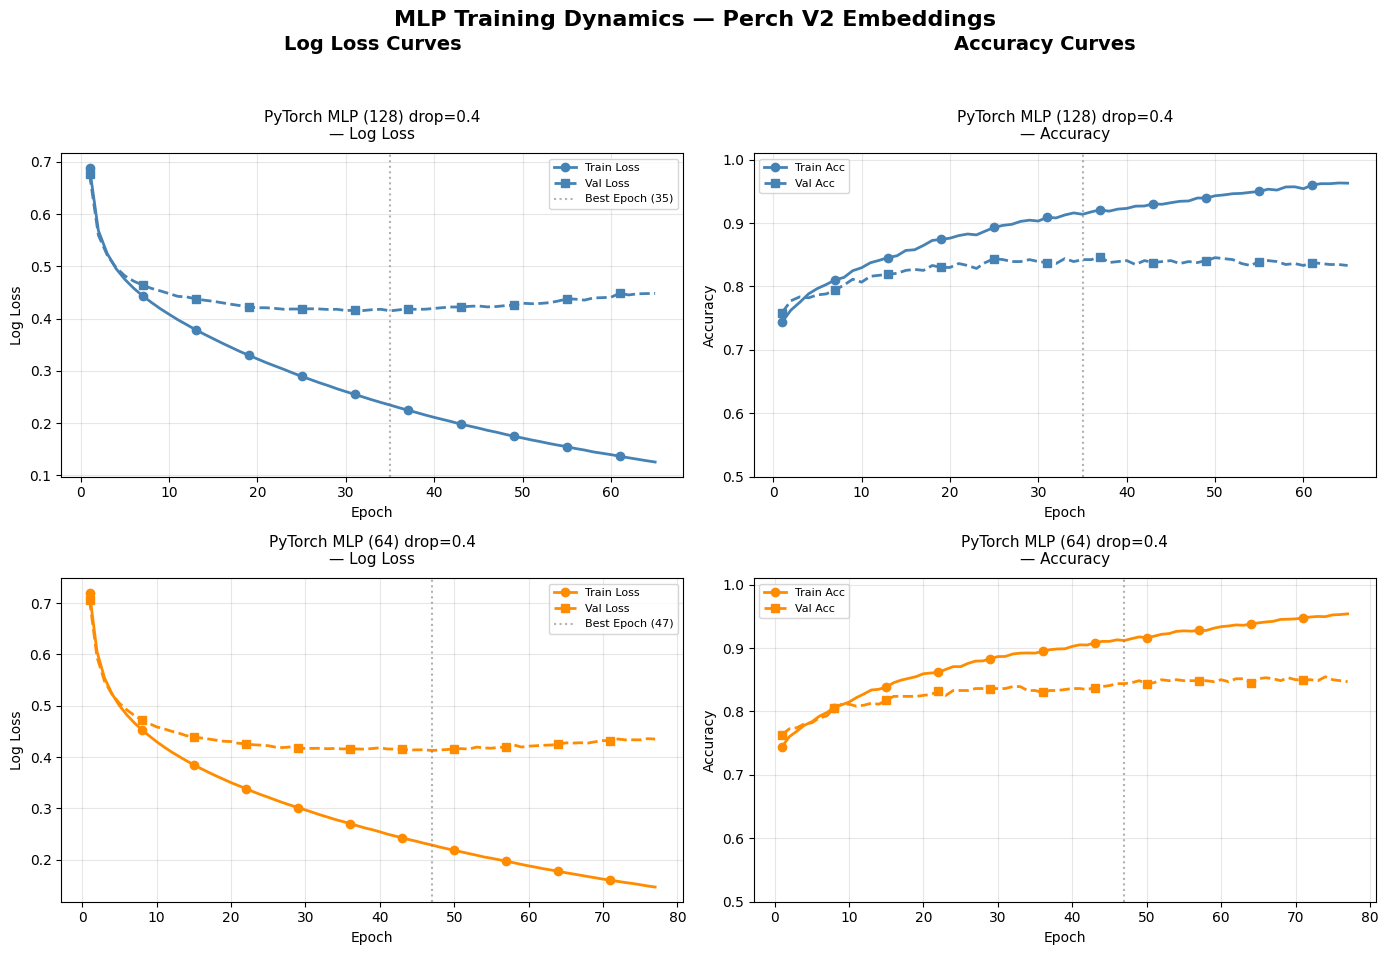

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

color_palette = ['steelblue', 'darkorange', 'seagreen']
colors = {name: color_palette[i % len(color_palette)] for i, name in enumerate(mlp_results)}

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing works

fig.suptitle('MLP Training Dynamics on 3 classes — Perch V2 Embeddings',
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, res) in enumerate(mlp_results.items()):
    color = colors[name]
    epochs = np.arange(1, res['n_iter'] + 1)

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                 color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                 color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                    label=f'Best Epoch ({res["best_epoch"]})')
    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.5, 1.01)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves', fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves', fontsize=14, fontweight='bold', ha='center')

plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
#@title PyTorch MLP with Dropout (5-class) + ROC curves + Training Dynamics

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import copy
import time
import matplotlib.pyplot as plt

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs_5c = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

n_classes_5c = len(class_names)

def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Class weights
class_counts_5c = np.bincount(y_train)
class_weights_5c = torch.tensor(
    [class_counts_5c.sum() / (n_classes_5c * c) for c in class_counts_5c],
    dtype=torch.float32
).to(device)
print(f'Class weights: {dict(zip(class_names, class_weights_5c.cpu().numpy().round(3)))}')

mlp_results_5c = {}

for name, cfg in torch_mlp_configs_5c.items():
    print(f'\nTraining {name}...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train, test_size=0.15,
        random_state=random_seed, stratify=y_train
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    model     = build_mlp(X_train_sc.shape[1], cfg['hidden'], cfg['dropout'], n_classes_5c).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights_5c)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_epoch = 0
    early_stopped = False

    t0 = time.time()
    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)
            tr_loss  = criterion(tr_logits, y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc   = (tr_logits.argmax(1) == y_tr_t).float().mean().item()
            val_acc  = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss); val_losses.append(val_loss)
        train_accs.append(tr_acc); val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0

    f1_macro     = f1_score(y_test, test_pred, average='macro')
    f1_per_class = f1_score(y_test, test_pred, average=None, labels=range(n_classes_5c))
    test_acc     = accuracy_score(y_test, test_pred)
    try:
        auc_ovr = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    mlp_results_5c[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': len(train_losses),
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped,
    }

    print(f'  Epochs: {len(train_losses)} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train: {train_accs[-1]:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | AUC: {auc_ovr:.4f}')
    print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0))

Using device: cuda
Class weights: {'background': 0.378, 'burst_pulse': 2.508, 'echolocation': 2.472, 'feeding_buzz': 4.313, 'whistle': 0.757}

Training PyTorch MLP (128) drop=0.4...
  Epochs: 56 | Best: 26 | Early stop: True
  Time: 2.9s | Train: 0.8966 | Test: 0.7426 | Macro F1: 0.6171 | AUC: 0.9429
              precision    recall  f1-score   support

  background       0.93      0.75      0.83       978
 burst_pulse       0.37      0.57      0.45       148
echolocation       0.34      0.52      0.41       149
feeding_buzz       0.42      0.67      0.52        85
     whistle       0.89      0.86      0.87       489

    accuracy                           0.74      1849
   macro avg       0.59      0.67      0.62      1849
weighted avg       0.80      0.74      0.76      1849


Training PyTorch MLP (64) drop=0.4...
  Epochs: 62 | Best: 32 | Early stop: True
  Time: 3.5s | Train: 0.8584 | Test: 0.7312 | Macro F1: 0.6074 | AUC: 0.9425
              precision    recall  f1-score   supp

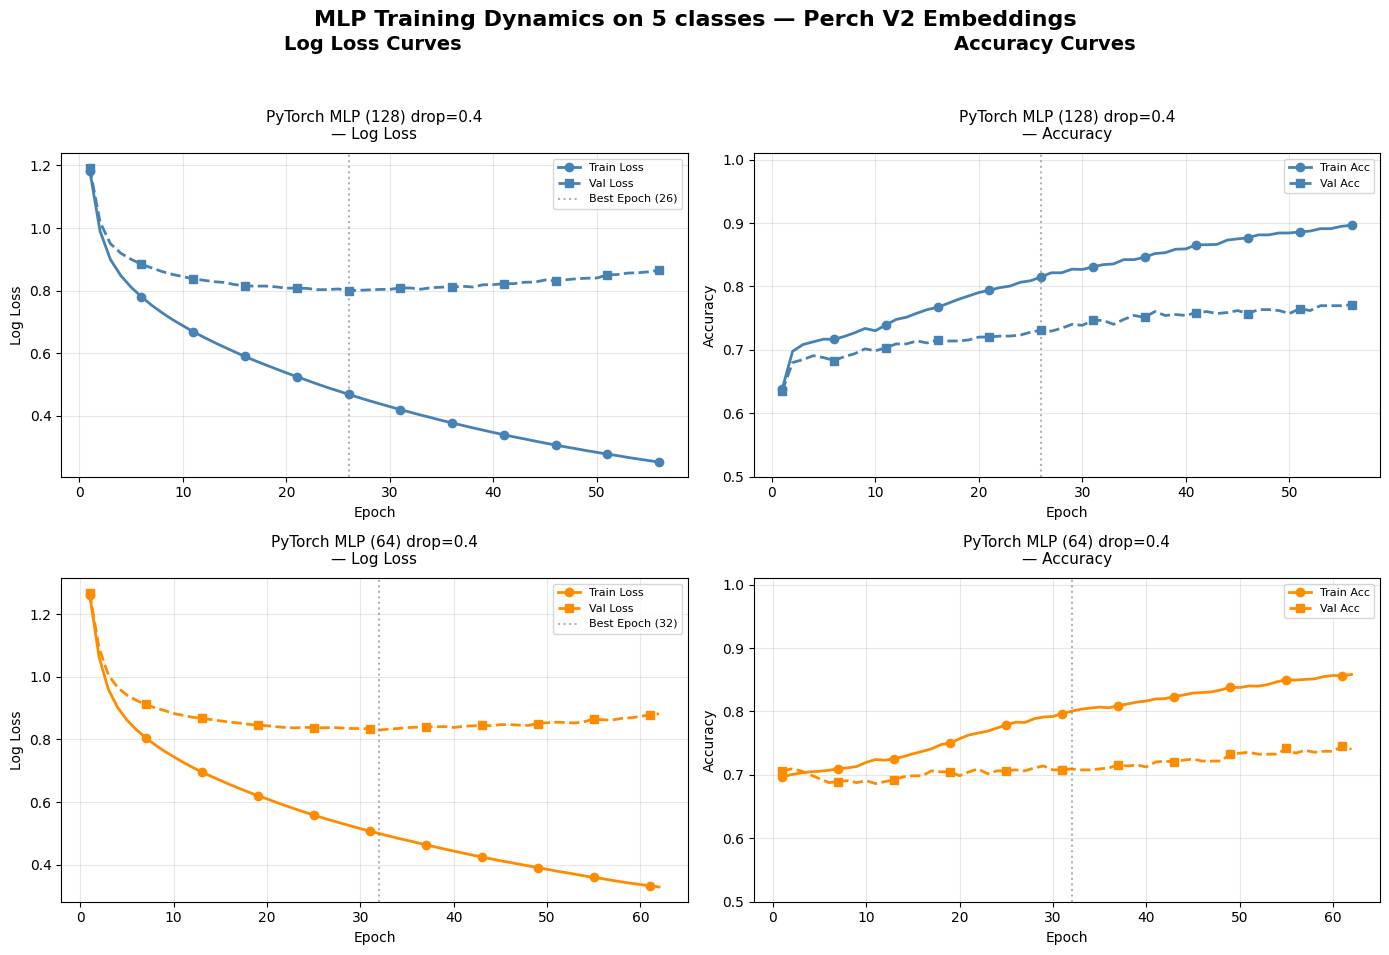

In [18]:
# ── Training Dynamics Plot ────────────────────────────────────────────────────
color_palette = ['steelblue', 'darkorange', 'seagreen']
colors_dyn = {name: color_palette[i % len(color_palette)] for i, name in enumerate(mlp_results_5c)}

n_models = len(mlp_results_5c)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

fig.suptitle('MLP Training Dynamics on 5 classes — Perch V2 Embeddings',
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, res) in enumerate(mlp_results_5c.items()):
    color = colors_dyn[name]
    epochs = np.arange(1, res['n_iter'] + 1)

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                 color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                 color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                    label=f'Best Epoch ({res["best_epoch"]})')
    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.5, 1.01)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves', fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves', fontsize=14, fontweight='bold', ha='center')

plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics_5class.png', dpi=150, bbox_inches='tight')
plt.show()

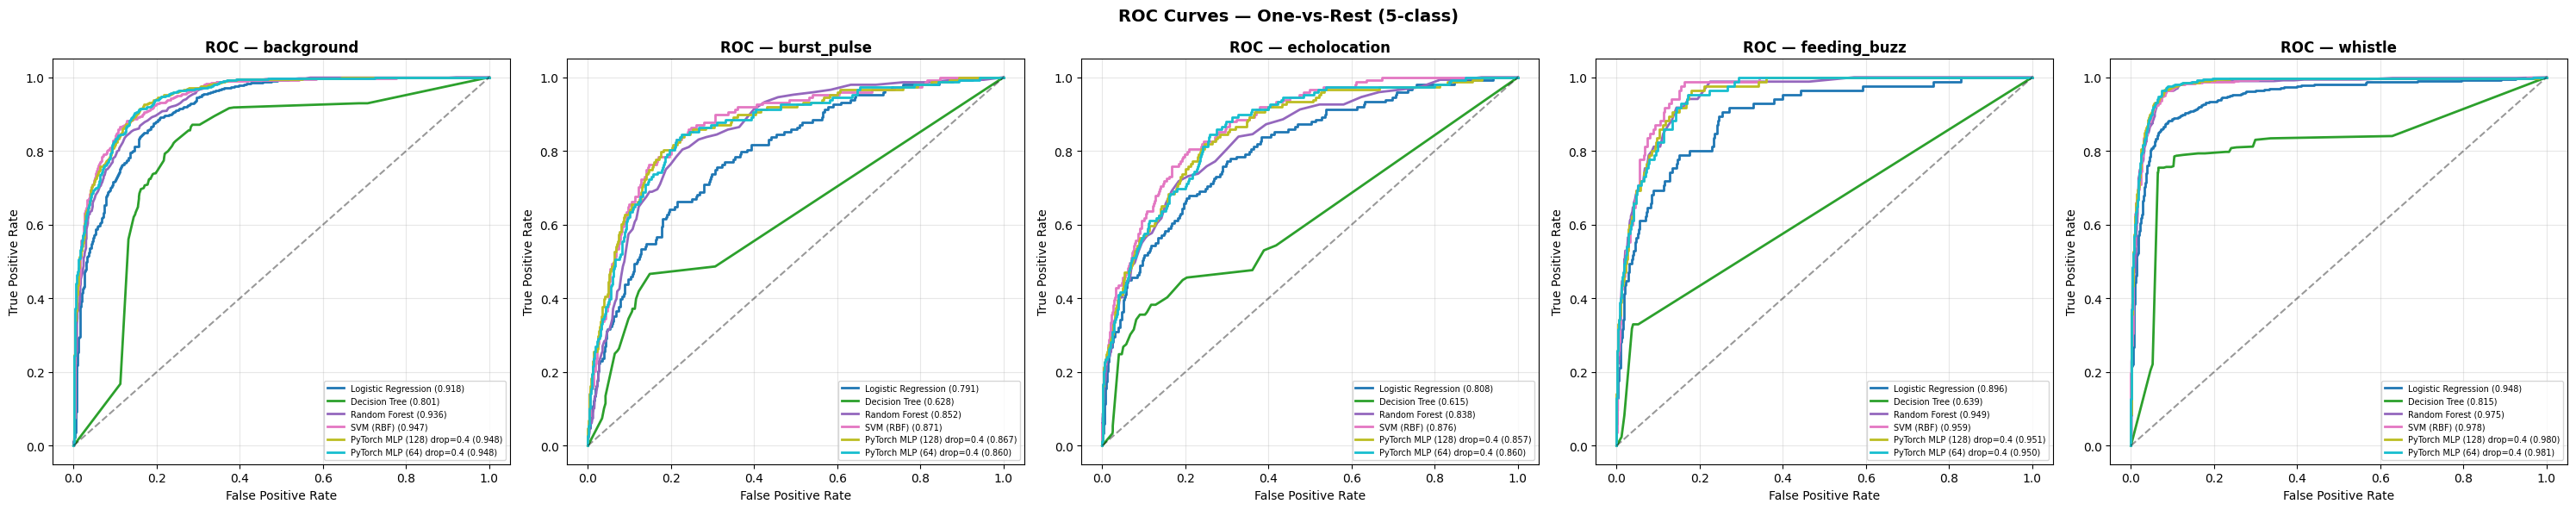

In [19]:
# ── 5-class ROC: sklearn results + MLP results ───────────────────────────────
all_5c = {**results, **mlp_results_5c}

y_test_bin_5c = label_binarize(y_test, classes=range(n_classes_5c))

fig, axes = plt.subplots(1, n_classes_5c, figsize=(6 * n_classes_5c, 6))
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_5c)))

for class_idx, (cn, ax) in enumerate(zip(class_names, axes)):
    for model_idx, (name, res) in enumerate(all_5c.items()):
        proba = res['y_proba']
        fpr, tpr, _ = roc_curve(y_test_bin_5c[:, class_idx], proba[:, class_idx])
        auc = roc_auc_score(y_test_bin_5c[:, class_idx], proba[:, class_idx])
        ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=colors_roc[model_idx], linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {cn}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — One-vs-Rest (5-class)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/roc_curves_5class.png', dpi=150, bbox_inches='tight')
plt.show()

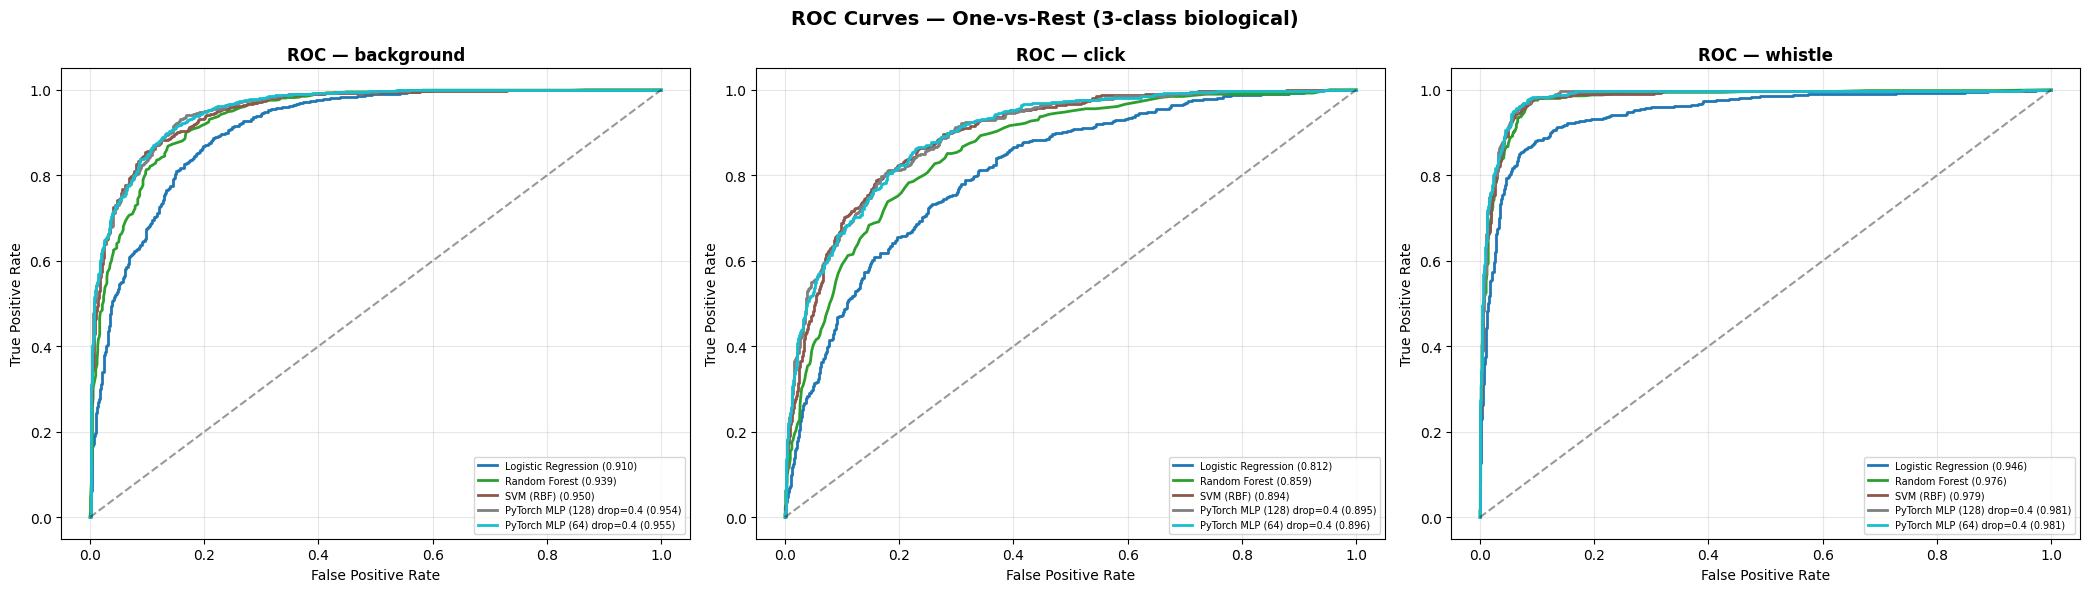

In [21]:
#@title ROC Curves — ALL classifiers (3-class biological, one-vs-rest)

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

# Retrain sklearn on 3-class labels (same split, same scaled features)
sklearn_3c = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
    ),
}

results_3c = {}
for name, clf in sklearn_3c.items():
    clf.fit(X_train_sc, y_train_3c)
    results_3c[name] = {'y_proba': clf.predict_proba(X_test_sc)}

# Add MLP results (already 3-class)
for name, res in mlp_results.items():
    results_3c[name] = res

# Plot
y_test_bin_3c = label_binarize(y_test_3c, classes=range(n_classes_3c))

fig, axes = plt.subplots(1, n_classes_3c, figsize=(7 * n_classes_3c, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(results_3c)))

for class_idx, (cn, ax) in enumerate(zip(class_names_3c, axes)):
    for model_idx, (name, res) in enumerate(results_3c.items()):
        proba = res['y_proba']
        fpr, tpr, _ = roc_curve(y_test_bin_3c[:, class_idx], proba[:, class_idx])
        auc = roc_auc_score(y_test_bin_3c[:, class_idx], proba[:, class_idx])
        ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=colors[model_idx], linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {cn}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — One-vs-Rest (3-class biological)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/roc_curves_3class.png', dpi=150, bbox_inches='tight')
plt.show()

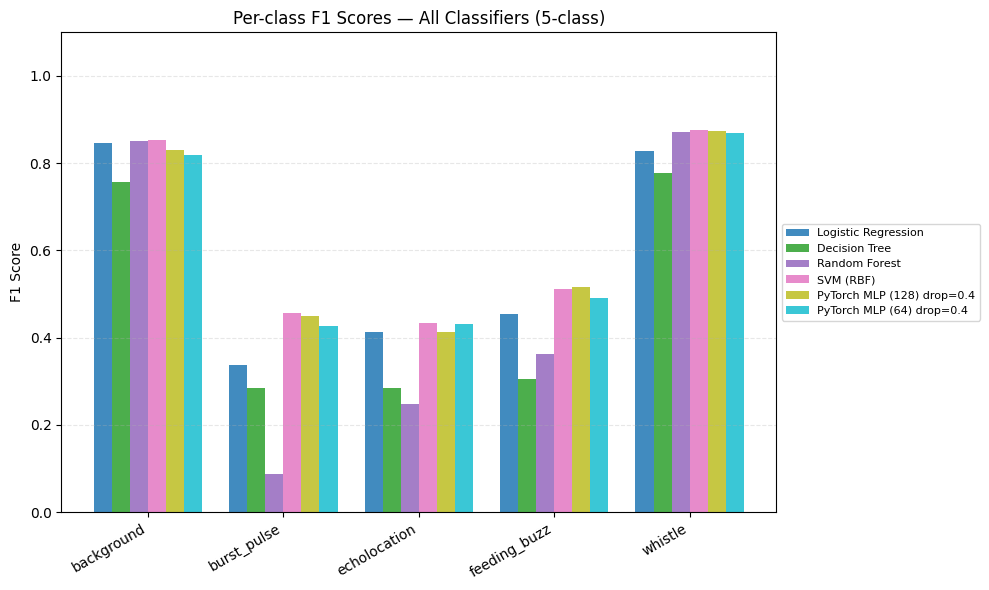

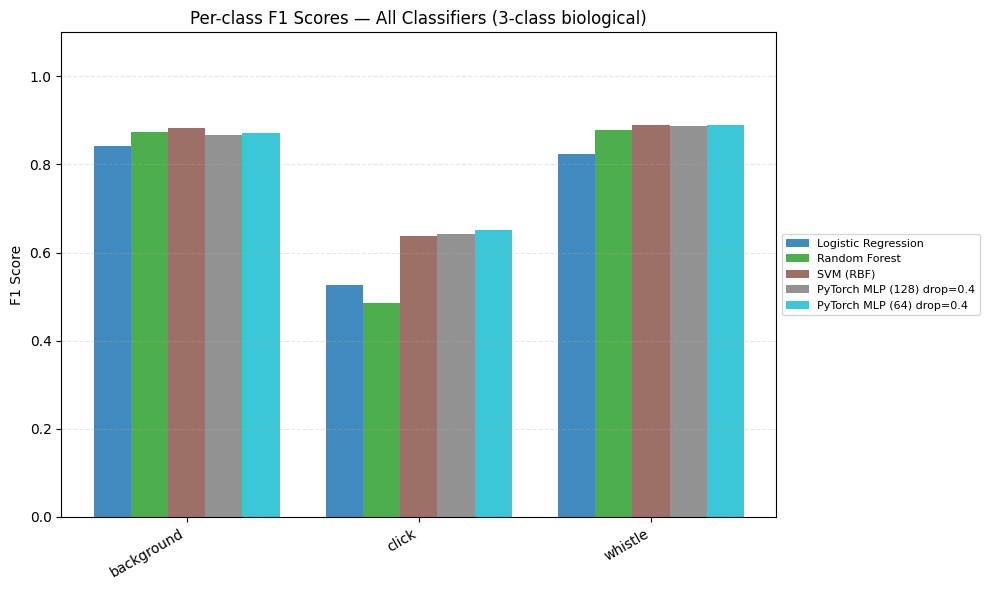

In [23]:
#@title Per-class F1 comparison bar chart — 5-class and 3-class

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# ── 5-class ───────────────────────────────────────────────────────────────────
all_5c = {**results, **mlp_results_5c}

n_clf_5c = len(all_5c)
n_cls_5c = len(class_names)

colors_5c = plt.cm.tab10(np.linspace(0, 1, min(n_clf_5c, 10)))
x_5c = np.arange(n_cls_5c)
width_5c = 0.8 / n_clf_5c

fig, ax = plt.subplots(figsize=(max(10, n_cls_5c * 2), 6))

for i, (name, res) in enumerate(all_5c.items()):
    f1_per = f1_score(y_test, res['y_pred'],
                      labels=list(range(n_cls_5c)), average=None, zero_division=0)
    offset = (i - n_clf_5c / 2 + 0.5) * width_5c
    ax.bar(x_5c + offset, f1_per, width_5c, label=name,
           color=colors_5c[i % len(colors_5c)], alpha=0.85)

ax.set_xticks(x_5c)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers (5-class)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers_5class.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3-class (biological) — uses results_3c from ROC cell ─────────────────────
n_clf_3c = len(results_3c)

colors_3c = plt.cm.tab10(np.linspace(0, 1, min(n_clf_3c, 10)))
x_3c = np.arange(n_classes_3c)
width_3c = 0.8 / n_clf_3c

fig, ax = plt.subplots(figsize=(max(10, n_classes_3c * 2), 6))

for i, (name, res) in enumerate(results_3c.items()):
    y_pred_i = res['y_pred'] if 'y_pred' in res else res['y_proba'].argmax(axis=1)
    f1_per = f1_score(y_test_3c, y_pred_i,
                      labels=list(range(n_classes_3c)), average=None, zero_division=0)
    offset = (i - n_clf_3c / 2 + 0.5) * width_3c
    ax.bar(x_3c + offset, f1_per, width_3c, label=name,
           color=colors_3c[i % len(colors_3c)], alpha=0.85)

ax.set_xticks(x_3c)
ax.set_xticklabels(class_names_3c, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers (3-class biological)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers_3class.png', dpi=150, bbox_inches='tight')
plt.show()

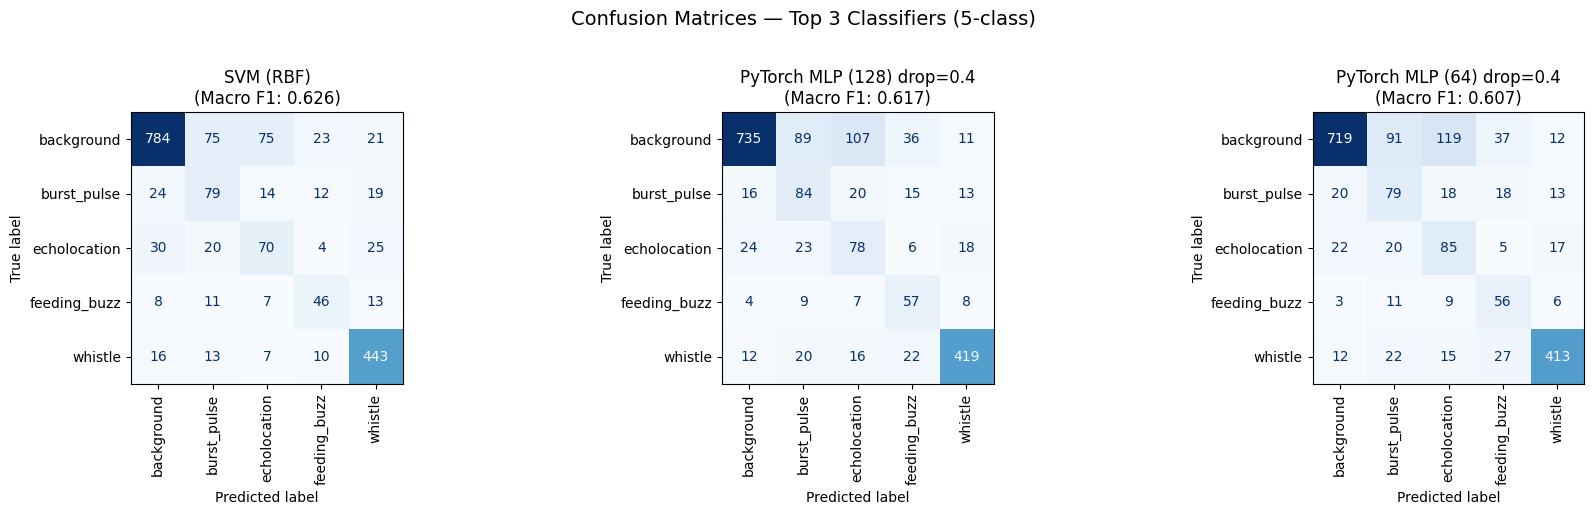

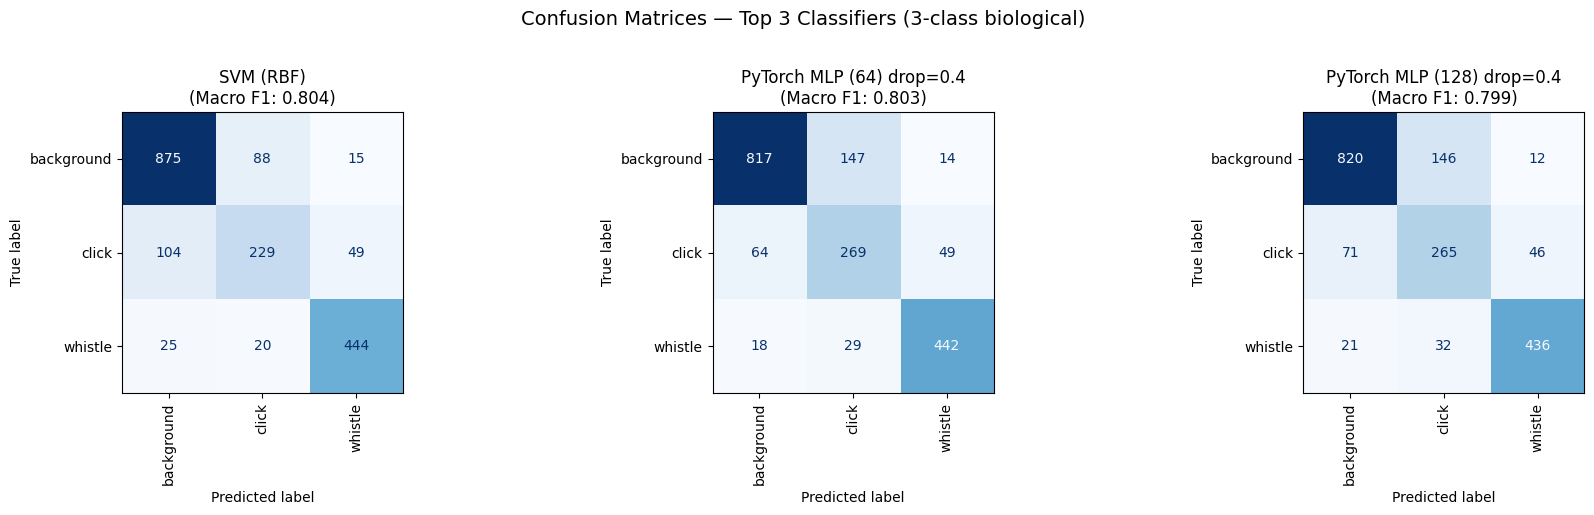

In [24]:
#@title Confusion matrices — Top N classifiers by Macro F1 (5-class and 3-class)
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

TOP_N = 3

# ── 5-class ───────────────────────────────────────────────────────────────────
all_5c = {**results, **mlp_results_5c}
top_5c = sorted(all_5c.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(6 * TOP_N, 5))
if TOP_N == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, top_5c):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=class_names,
        ax=ax, colorbar=False, xticks_rotation='vertical', cmap='Blues'
    )
    ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})')

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (5-class)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}_5class.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3-class (biological) — uses results_3c from ROC cell ─────────────────────
# Compute macro F1 and y_pred for all entries
results_3c_ranked = []
for name, res in results_3c.items():
    y_pred_i = res['y_pred'] if 'y_pred' in res else res['y_proba'].argmax(axis=1)
    f1_macro = f1_score(y_test_3c, y_pred_i, average='macro', zero_division=0)
    results_3c_ranked.append((name, y_pred_i, f1_macro))

results_3c_ranked.sort(key=lambda x: x[2], reverse=True)
top_3c = results_3c_ranked[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(6 * TOP_N, 5))
if TOP_N == 1:
    axes = [axes]

for ax, (name, y_pred_i, f1_macro) in zip(axes, top_3c):
    ConfusionMatrixDisplay.from_predictions(
        y_test_3c, y_pred_i,
        display_labels=class_names_3c,
        ax=ax, colorbar=False, xticks_rotation='vertical', cmap='Blues'
    )
    ax.set_title(f'{name}\n(Macro F1: {f1_macro:.3f})')

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (3-class biological)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}_3class.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
#@title Save full results to CSV — ALL classifiers (5-class and 3-class)
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, f1_score
import pandas as pd

# ── 5-class ───────────────────────────────────────────────────────────────────
all_5c = {**results, **mlp_results_5c}

rows_5c = []
for name, res in all_5c.items():
    auc = None
    if 'y_proba' in res and res['y_proba'].ndim == 2:
        try:
            auc = roc_auc_score(y_test, res['y_proba'], multi_class='ovr', average='weighted')
        except ValueError:
            auc = None

    p, r, f, s = precision_recall_fscore_support(
        y_test, res['y_pred'], labels=range(len(class_names)), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'roc_auc_ovr': auc,
        'time_seconds': res.get('time_s', None),
    }
    for i, cls in enumerate(class_names):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall'] = round(r[i], 3)
        row[f'{cls}_f1'] = round(f[i], 3)
        row[f'{cls}_support'] = s[i]
    rows_5c.append(row)

results_df_5c = pd.DataFrame(rows_5c)
cols_5c = ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds'] + \
          [c for c in results_df_5c.columns if c not in ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds']]
results_df_5c = results_df_5c[cols_5c]

results_df_5c.to_csv(f'{save_dir}/perch_v2_all_classifiers_results_5class.csv', index=False)
print(f'Saved {len(results_df_5c)} classifiers to {save_dir}/perch_v2_all_classifiers_results_5class.csv')
display(results_df_5c.round(3))

# ── 3-class (biological) — uses results_3c from ROC cell ─────────────────────
rows_3c = []
for name, res in results_3c.items():
    y_pred_i = res['y_pred'] if 'y_pred' in res else res['y_proba'].argmax(axis=1)

    auc = None
    if 'y_proba' in res and res['y_proba'].ndim == 2:
        try:
            auc = roc_auc_score(y_test_3c, res['y_proba'], multi_class='ovr', average='weighted')
        except ValueError:
            auc = None

    macro_f1 = f1_score(y_test_3c, y_pred_i, average='macro', zero_division=0)

    p, r, f, s = precision_recall_fscore_support(
        y_test_3c, y_pred_i, labels=range(n_classes_3c), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': macro_f1,
        'roc_auc_ovr': auc,
        'time_seconds': res.get('time_s', None),
    }
    for i, cls in enumerate(class_names_3c):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall'] = round(r[i], 3)
        row[f'{cls}_f1'] = round(f[i], 3)
        row[f'{cls}_support'] = s[i]
    rows_3c.append(row)

results_df_3c = pd.DataFrame(rows_3c)
cols_3c = ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds'] + \
          [c for c in results_df_3c.columns if c not in ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds']]
results_df_3c = results_df_3c[cols_3c]

results_df_3c.to_csv(f'{save_dir}/perch_v2_all_classifiers_results_3class.csv', index=False)
print(f'\nSaved {len(results_df_3c)} classifiers to {save_dir}/perch_v2_all_classifiers_results_3class.csv')
display(results_df_3c.round(3))

Saved 6 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/OLTREMARE/perch_v2_all_classifiers_results_5class.csv


,classifier,macro_f1,roc_auc_ovr,time_seconds,background_precision,background_recall,background_f1,background_support,burst_pulse_precision,burst_pulse_recall,...,echolocation_f1,echolocation_support,feeding_buzz_precision,feeding_buzz_recall,feeding_buzz_f1,feeding_buzz_support,whistle_precision,whistle_recall,whistle_f1,whistle_support
0,Logistic Regression,0.576,0.906,0.949,0.851,0.843,0.847,978,0.353,0.324,...,0.412,149,0.420,0.494,0.454,85,0.851,0.808,0.829,489
1,Decision Tree,0.482,0.769,7.279,0.823,0.699,0.756,978,0.232,0.372,...,0.284,149,0.286,0.329,0.306,85,0.804,0.755,0.778,489
2,Random Forest,0.484,0.932,1.433,0.758,0.970,0.851,978,0.500,0.047,...,0.247,149,0.677,0.247,0.362,85,0.843,0.902,0.872,489
3,SVM (RBF),0.626,0.944,63.692,0.910,0.802,0.852,978,0.399,0.534,...,0.435,149,0.484,0.541,0.511,85,0.850,0.906,0.877,489
4,PyTorch MLP (128) drop=0.4,0.617,0.943,2.937,0.929,0.752,0.831,978,0.373,0.568,...,0.414,149,0.419,0.671,0.516,85,0.893,0.857,0.875,489
5,PyTorch MLP (64) drop=0.4,0.607,0.942,3.516,0.927,0.735,0.820,978,0.354,0.534,...,0.430,149,0.392,0.659,0.491,85,0.896,0.845,0.869,489



Saved 5 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/OLTREMARE/perch_v2_all_classifiers_results_3class.csv


,classifier,macro_f1,roc_auc_ovr,time_seconds,background_precision,background_recall,background_f1,background_support,click_precision,click_recall,click_f1,click_support,whistle_precision,whistle_recall,whistle_f1,whistle_support
0,Logistic Regression,0.731,0.900,NaN,0.836,0.850,0.843,978,0.526,0.529,0.527,382,0.839,0.808,0.823,489
1,Random Forest,0.746,0.932,NaN,0.815,0.939,0.873,978,0.718,0.366,0.485,382,0.847,0.914,0.879,489
2,SVM (RBF),0.804,0.946,NaN,0.872,0.895,0.883,978,0.680,0.599,0.637,382,0.874,0.908,0.891,489
3,PyTorch MLP (128) drop=0.4,0.799,0.949,3.952,0.899,0.838,0.868,978,0.598,0.694,0.642,382,0.883,0.892,0.887,489
4,PyTorch MLP (64) drop=0.4,0.803,0.950,4.117,0.909,0.835,0.871,978,0.604,0.704,0.651,382,0.875,0.904,0.889,489


# 5-classs dimensionality reduction

Running full PCA...

Total components: 1536

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                 11.1924         11.1924
      PC2                  5.4543         16.6468
      PC3                  3.6965         20.3433
      PC4                  2.7132         23.0565
      PC5                  2.4586         25.5151
      PC6                  1.9942         27.5093
      PC7                  1.8169         29.3262
      PC8                  1.7484         31.0745
      PC9                  1.4073         32.4819
     PC10                  1.3294         33.8113
     PC11                  1.2682         35.0795
     PC12                  1.1740         36.2535
     PC13                  1.0752         37.3287
     PC14                  1.0004         38.3291
     PC15                  0.9659         39.2951
     PC16                  0.9279         40.2229
     PC17                  0.8848         41.1077
     PC18

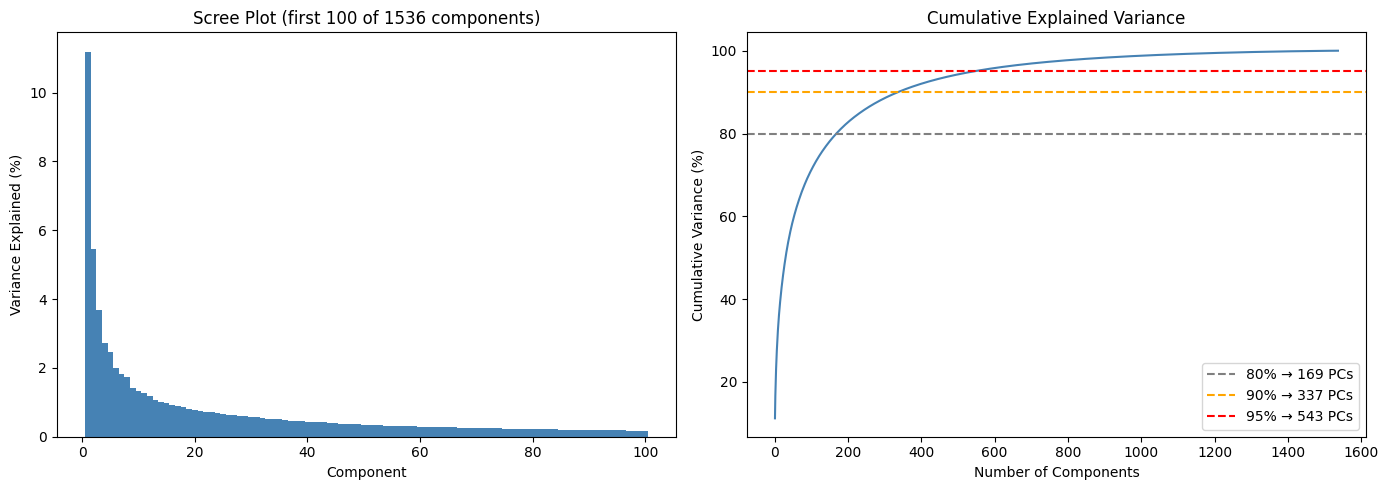

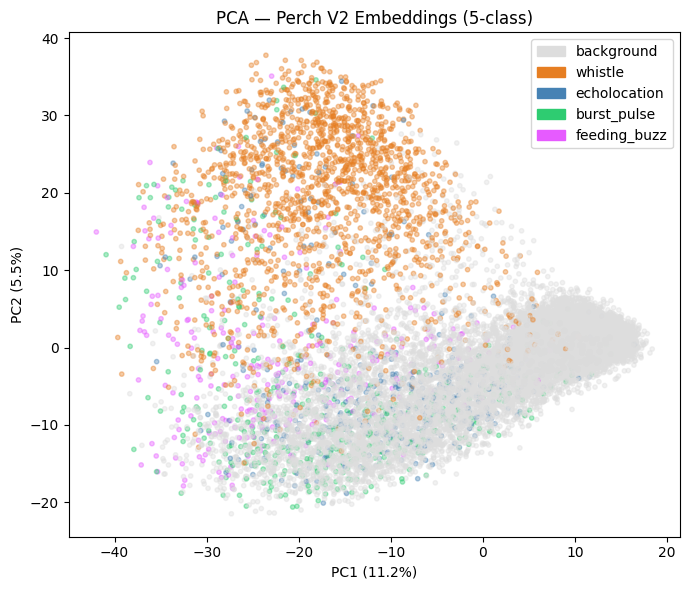


PCA-reduced shape for t-SNE/UMAP input: (16860, 337)

Running t-SNE with multiple distance metrics...
  t-SNE metric: euclidean...
  t-SNE metric: cosine...
  t-SNE metric: manhattan...
  t-SNE metric: correlation...


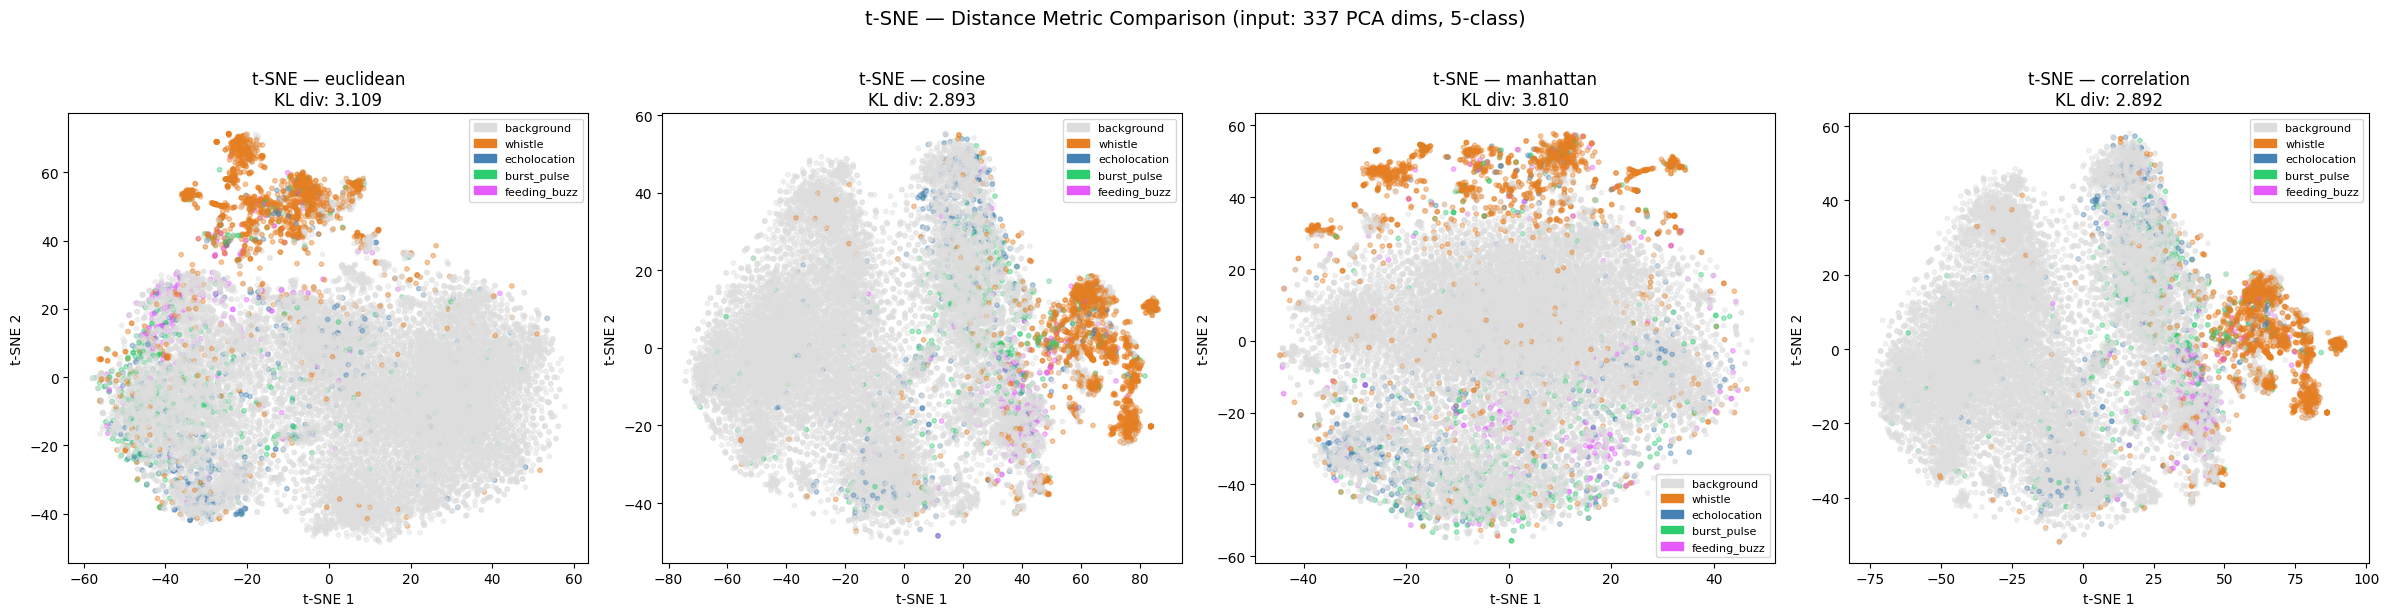


Running UMAP with multiple distance metrics...
  UMAP metric: euclidean...
  UMAP metric: cosine...
  UMAP metric: manhattan...
  UMAP metric: correlation...


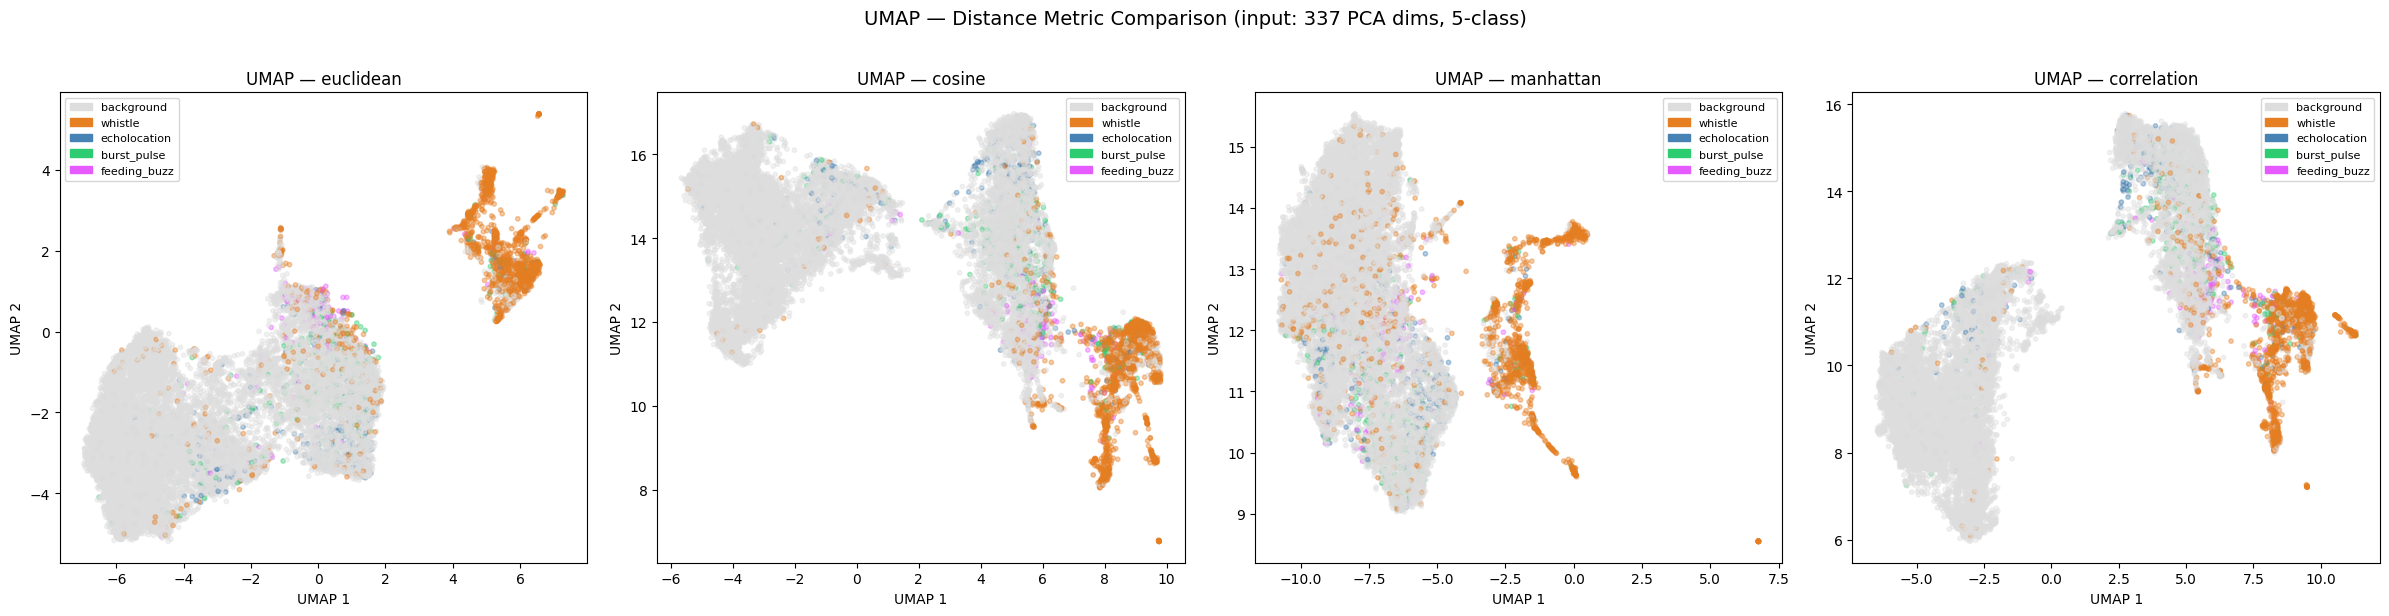


SUMMARY
PCA input dims: 1536 → reduced to 337 (90% variance)

t-SNE KL Divergence by metric (lower = better fit):
  correlation      KL: 2.8924
  cosine           KL: 2.8933
  euclidean        KL: 3.1092
  manhattan        KL: 3.8102

All coordinates saved.


In [33]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (5-class)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup — 5 classes
colors_5c_map = {
    'background': "#DDDDDD",
    'whistle': '#e67e22',
    'echolocation': '#4682b4',
    'burst_pulse': '#2ecc71',
    'feeding_buzz': "#e65bff",
}
c = np.array([colors_5c_map[label] for label in y_clean])
alpha = 0.4
s = 10
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_5c_map.items()]

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

n80 = np.argmax(cumvar_full >= 80) + 1
n90 = np.argmax(cumvar_full >= 90) + 1
n95 = np.argmax(cumvar_full >= 95) + 1
n99 = np.argmax(cumvar_full >= 99) + 1
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE/UMAP input (90% variance)')

# Scree + cumulative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray', linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red', linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance_5class.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings (5-class)')
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d_5class_improved.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input
# ═══════════════════════════════════════════════════════════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE with multiple distance metrics...')
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000,
        metric=metric,
        random_state=random_seed,
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne.kl_divergence_:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(handles=legend_patches, fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison (input: {n_pca} PCA dims, 5-class)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison_5class_improved.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(handles=legend_patches, fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison (input: {n_pca} PCA dims, 5-class)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison_5class_improved.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

# Save all coordinates
np.save(f'{save_dir}/dim_red/coords_pca2_5class.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}_5class.npy', tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}_5class.npy', umap_results[metric])
print('\nAll coordinates saved.')

In [29]:
#@title Quantitative quality metrics — 5-class
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRICS (5-class)')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

# Use actual 5-class labels (encoded as ints for silhouette)
le_viz = LabelEncoder()
y_viz = le_viz.fit_transform(y_clean)

# t-SNE quality
for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_viz)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# UMAP quality
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_viz)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# PCA baseline
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_viz)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')


QUANTITATIVE QUALITY METRICS (5-class)
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------


t-SNE                euclidean                 0.9026       0.0371
t-SNE                cosine                    0.9151       0.0216
t-SNE                manhattan                 0.8601       0.0456
t-SNE                correlation               0.9144       0.0223

UMAP                 euclidean                 0.8335       0.1445
UMAP                 cosine                    0.8506       0.0820
UMAP                 manhattan                 0.7849       0.0582
UMAP                 correlation               0.8447       0.0775

PCA (2D)             euclidean                 0.7004       0.2257


Now we look at how the 3-class separation compares

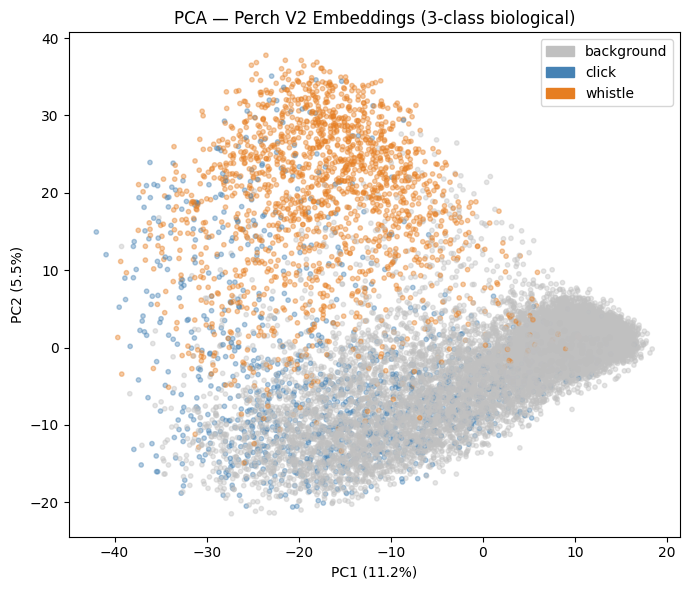

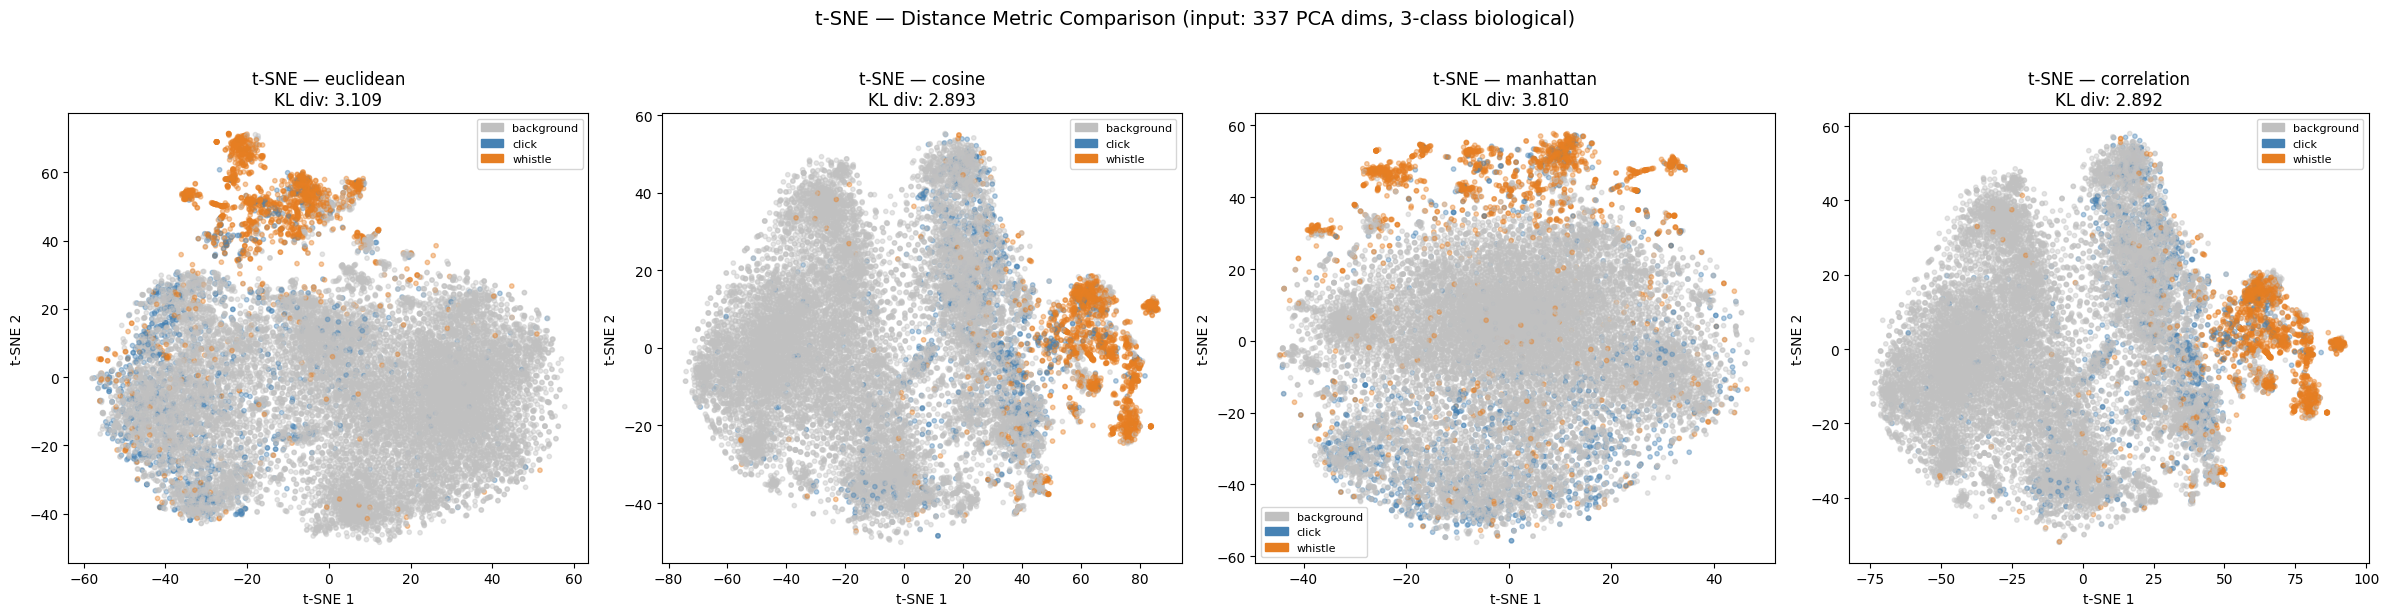

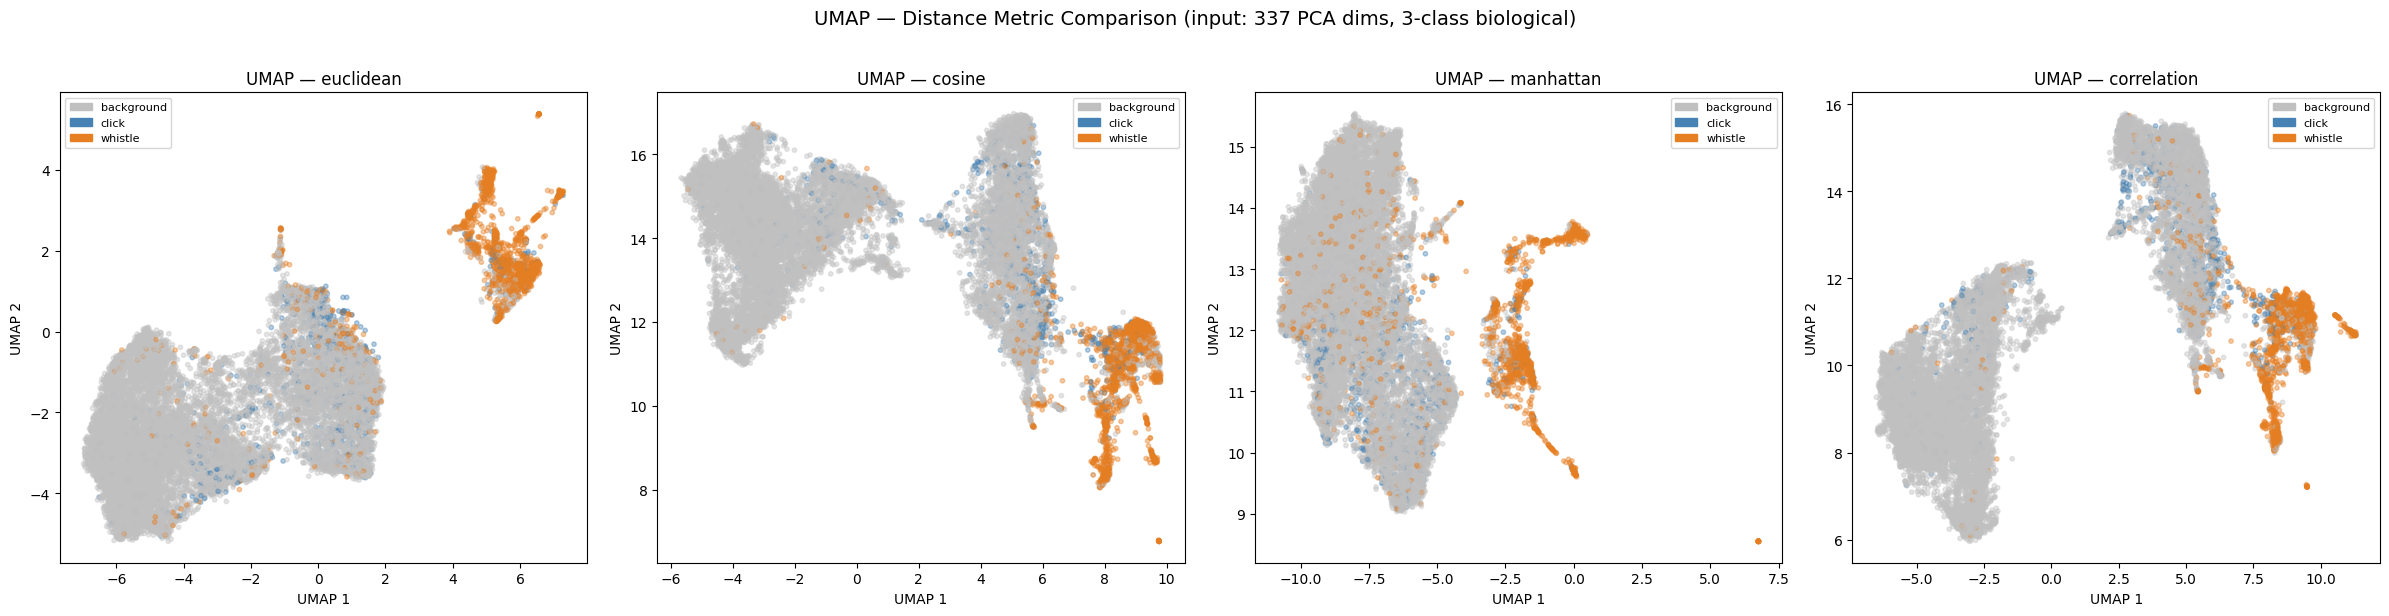


QUANTITATIVE QUALITY METRICS (3-class biological)
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------
t-SNE                euclidean                 0.9026       0.1248
t-SNE                cosine                    0.9151       0.1126
t-SNE                manhattan                 0.8601       0.0940
t-SNE                correlation               0.9144       0.1135

UMAP                 euclidean                 0.8335       0.2136
UMAP                 cosine                    0.8506       0.1631
UMAP                 manhattan                 0.7849       0.1607
UMAP                 correlation               0.8447       0.1611

PCA (2D)             euclidean                 0.7004       0.3340

All 3-class coordinates saved.


In [31]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (3-class biological)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Remap to 3-class biological
label_remap_viz = {
    'background': 'background',
    'whistle': 'whistle',
    'echolocation': 'click',
    'burst_pulse': 'click',
    'feeding_buzz': 'click',
}
y_clean_3c = np.array([label_remap_viz[label] for label in y_clean])

# Color setup — 3 classes
colors_3c_map = {
    'background': '#C0C0C0',
    'click': '#4682b4',
    'whistle': '#e67e22',
}
c_3c = np.array([colors_3c_map[label] for label in y_clean_3c])
alpha = 0.4
s = 10
legend_patches_3c = [mpatches.Patch(color=v, label=k) for k, v in colors_3c_map.items()]

# Reuse X_scaled, X_pca2, X_pca_red, n_pca from 5-class cell

# ═══════════════════════════════════════════════════════════════════════════════
# 1. PCA 2D scatter (same coords, different coloring)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c_3c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings (3-class biological)')
ax.legend(handles=legend_patches_3c)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d_3class.png', dpi=150)
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. t-SNE — reuse coords from 5-class, just recolor
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, metric in zip(axes, metrics):
    X_tsne = tsne_results[metric]['coords']
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c_3c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne_results[metric]["kl"]:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(handles=legend_patches_3c, fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison (input: {n_pca} PCA dims, 3-class biological)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison_3class.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 3. UMAP — reuse coords from 5-class, just recolor
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, metric in zip(axes, metrics):
    X_umap = umap_results[metric]
    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c_3c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(handles=legend_patches_3c, fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison (input: {n_pca} PCA dims, 3-class biological)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison_3class.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. Quantitative quality metrics — 3-class
# ═══════════════════════════════════════════════════════════════════════════════
le_viz_3c = LabelEncoder()
y_viz_3c = le_viz_3c.fit_transform(y_clean_3c)

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRICS (3-class biological)')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_viz_3c)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_viz_3c)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_viz_3c)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')

# Save 3-class coloured coords
np.save(f'{save_dir}/dim_red/coords_pca2_3class.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}_3class.npy', tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}_3class.npy', umap_results[metric])
print('\nAll 3-class coordinates saved.')

In [2]:
# ── PCA — 5-class vocalization types, thesis plotly style (self-contained) ───
import os, glob
import numpy as np
import pandas as pd
import plotly.express as px

save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/OLTREMARE'

GREY, FONT = "#5a5a5a", "Helvetica Neue, Arial, sans-serif"

# Thesis palette — background greyed out, 4 vocalizations get the thesis colours
colors_5c_map = {
    'background':   '#D2D3D4',   # neutral grey (recedes)
    'whistle':      '#2f9292',   # teal
    'echolocation': '#EF9F27',   # amber
    'burst_pulse':  '#7b5bc9',   # violet
    'feeding_buzz': '#D85A30',   # coral
}
ORDER = list(colors_5c_map.keys())   # background drawn first (underneath)

# 1. PCA coords — in-memory first, else disk (_5class suffix)
def _load_pca():
    if 'X_pca2' in globals():  return X_pca2
    for pat in ['coords_pca2_5class.npy', '*pca2*5class*.npy', 'coords_pca2.npy']:
        hits = glob.glob(f'{save_dir}/dim_red/{pat}')
        if hits:
            print('Loaded coords:', os.path.basename(hits[0]))
            return np.load(hits[0])
    raise FileNotFoundError(f"No PCA coords in memory or under {save_dir}/dim_red/.")
X_pca2 = _load_pca()

# 2. Labels — in-memory y_clean, else metadata.csv 'label', else y_labels.npy
def _load_labels():
    if 'y_clean' in globals():  return np.asarray(y_clean)
    meta_p = f'{save_dir}/embeddings/metadata.csv'
    if os.path.exists(meta_p):  return pd.read_csv(meta_p)['label'].values
    ylab_p = f'{save_dir}/embeddings/y_labels.npy'
    if os.path.exists(ylab_p):  return np.load(ylab_p, allow_pickle=True)
    raise FileNotFoundError("No labels (y_clean / metadata.csv / y_labels.npy) found.")
labels = _load_labels()

# 3. Alignment guard
assert len(labels) == X_pca2.shape[0], \
    f"labels ({len(labels)}) != coords ({X_pca2.shape[0]}) — not aligned!"

# 4. Explained variance — hardcode from the full PCA run output (PC1 / PC2)
var0, var1 = None, None   # ← e.g. 19.79, 5.65  (paste from the dim-red printout)
if var0 is None:
    xlab, ylab = "Component 1", "Component 2"
else:
    xlab, ylab = f"Component 1 ({var0:.1f}%)", f"Component 2 ({var1:.1f}%)"

# 5. Build figure
df = pd.DataFrame({"PC1": X_pca2[:, 0], "PC2": X_pca2[:, 1], "class": labels})
fig = px.scatter(df, x="PC1", y="PC2", color="class",
                 color_discrete_map=colors_5c_map, category_orders={"class": ORDER})
fig.update_traces(marker=dict(size=6, opacity=0.65, line=dict(width=0)))
fig.update_layout(
    template="plotly_white", width=820, height=560,
    paper_bgcolor="white", plot_bgcolor="white",
    font=dict(family=FONT, size=12, color=GREY),
    title=dict(text="PCA (EMBEDDINGS) — color: vocalization type",
               x=0.01, xanchor="left", y=0.97, font=dict(size=13, color=GREY)),
    margin=dict(l=70, r=180, t=60, b=60),
    legend=dict(title=dict(text="class", font=dict(size=12, color=GREY)),
                x=1.02, xanchor="left", y=1, yanchor="top",
                itemsizing="constant", font=dict(size=11, color=GREY),
                bgcolor="rgba(0,0,0,0)"),
    xaxis=dict(title=dict(text=xlab, font=dict(size=12, color=GREY)),
               tickfont=dict(size=8, color=GREY),
               showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
               zeroline=False, linecolor="#e3e3e3"),
    yaxis=dict(title=dict(text=ylab, font=dict(size=12, color=GREY)),
               tickfont=dict(size=8, color=GREY),
               showgrid=True, gridcolor="#e3e3e3", gridwidth=0.5,
               zeroline=False, linecolor="#e3e3e3"),
)
fig.show()

# 6. Save — PNG if Chrome/kaleido available, else interactive HTML
os.makedirs(f'{save_dir}/dim_red/repainted', exist_ok=True)
out = f'{save_dir}/dim_red/repainted/pca_5class_plotly'
try:
    fig.write_image(f'{out}.png', scale=3)
    print('Saved:', f'{out}.png')
except Exception as e:
    fig.write_html(f'{out}.html')
    print(f'PNG export failed ({type(e).__name__}); saved HTML instead: {out}.html')

PNG export failed (RuntimeError); saved HTML instead: /data2/mromaniuc/cet-det/models/perch_v2/OLTREMARE/dim_red/repainted/pca_5class_plotly.html
